In [1]:
print("Hello world")

Hello world


In [62]:
import pandas as pd
import numpy as np
from pymongo import MongoClient
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#connecting to MongoDB client
client = MongoClient(
    "mongodb://100.103.177.85:27017",
    directConnection=True,
    serverSelectionTimeoutMS=10000,
)

db = client["booktestdbgp_test"]
print("Connected ✅")

Connected ✅


: 

In [63]:
# Live Casino settled transactions only
# betParts ke andar se game name extract karna padega

raw_transactions = list(db["bet_transactions"].find(
    {
        "gameType": "Live Casino",
        "status": "SETTLED",
        "betParts": {"$exists": True, "$ne": []}
    }
))

transactions_df = pd.DataFrame(raw_transactions)
print(f"Raw transactions loaded: {len(transactions_df)}")
print(transactions_df.columns.tolist())

Raw transactions loaded: 197
['_id', 'category', 'gameType', 'ticketId', 'channel', 'status', 'createdDate', 'stake', 'currency', 'potentialPayout', 'isFreeBet', 'stakeBonus', 'stakeReal', 'minOdds', 'maxOdds', 'minPayout', 'maxPayout', 'freeBetId', 'bonusType', 'resultedDate', 'betType', 'betParts', 'cashoutHistory', 'dynamicMultiCorrectSelections', 'shortBetId', 'loginId', 'fromAccountId', 'fromAccountAmount', 'toAccountId', 'toAccountAmount', 'bonusAccountInfo', 'aggregatorId', 'aggregatorActionId', 'createdAt', 'updatedAt', '__v', 'payout', 'result', 'oddsChangeType', 'remainingStake', 'isPartialCoBet', 'totalOdds', 'cashoutStatus', 'bonusWinnings', 'bonusPercentage', 'groupCount', 'combinationCount', 'maxWinAmount', 'maxWinPercentage', 'clientMaxPayout', 'stakeTaxAmount', 'winningTaxAmount', 'stakeTax', 'winningTax', 'stakeAfterTax', 'totalStake', 'isNftHoldingCreated', 'isNftTraded', 'subBetType', 'betEligibleForOneCutBonus', 'betEligibleForTwoCutBonus', 'partialCoBet', 'maxPayou

In [64]:
# extracting first element of betParts array
# game name, vendor, category wahan hai

def extract_bet_part(betParts):
    if betParts and len(betParts) > 0:
        part = betParts[0]
        return {
            "sportName":    part.get("sportName", None),
            "categoryName": part.get("categoryName", None),
            "vendor":       part.get("tournamentName", None),
        }
    return {"sportName": None, "categoryName": None, "vendor": None}

bet_parts_expanded = transactions_df["betParts"].apply(extract_bet_part)
bet_parts_df = pd.DataFrame(bet_parts_expanded.tolist())

transactions_df = pd.concat(
    [transactions_df.drop(columns=["betParts"]), bet_parts_df], 
    axis=1
)

print(transactions_df[["loginId", "stake", "result", 
                         "sportName", "vendor", "categoryName"]].sample(5))

        loginId  stake result             sportName    vendor categoryName
159  4588888888    100   LOSE  Football Studio Dice     EvoSW  Live Casino
14   6258974310    107   LOSE                  None      None         None
43   6677777777     11    WIN                  None      None         None
16   6258974310    100   LOSE                  None      None         None
74   6258974310    107    WIN             Quantum X  OnlyPlay   Crash Game


In [65]:
# Rename fields to match recsys.ipynb schema
transactions_df = transactions_df.rename(columns={
    "loginId":      "userId",
    "stake":        "betAmount",
    "createdDate":  "timestamp",
    "sportName":    "gameName",
    "vendor":       "providerName",
})

# Time features
transactions_df["timestamp"] = pd.to_datetime(transactions_df["timestamp"])
transactions_df["hourOfDay"]  = transactions_df["timestamp"].dt.hour
transactions_df["dayOfWeek"]  = transactions_df["timestamp"].dt.day_name()

# Sirf jo chahiye
transactions_df = transactions_df[[
    "userId", "gameName", "providerName", "categoryName",
    "betAmount", "result",
    "timestamp", "hourOfDay", "dayOfWeek"
]].copy()

# Nulls drop
transactions_df = transactions_df.dropna(subset=["userId", "gameName", "betAmount"])

print(f"Clean transactions: {len(transactions_df)}")
print(transactions_df.dtypes)
print(transactions_df.sample(3))

Clean transactions: 144
userId                  object
gameName                object
providerName            object
categoryName            object
betAmount                int64
result                  object
timestamp       datetime64[ns]
hourOfDay                int32
dayOfWeek               object
dtype: object
         userId      gameName providerName categoryName  betAmount result  \
158  5555533333  Dragon Tiger        EvoSW  Live Casino        100    WIN   
173  9222222222  Dragon Tiger        EvoSW  Live Casino        100   LOSE   
114  7999999999  998:baccarat      Unknown       Casino        200   LOSE   

                  timestamp  hourOfDay  dayOfWeek  
158 2026-03-02 12:47:50.364         12     Monday  
173 2026-03-03 11:29:41.349         11    Tuesday  
114 2026-02-25 05:39:37.831          5  Wednesday  


In [66]:
#load games 

games_raw = list(db["gamedetails"].find(
    {"gameStatus": "ON"},
    {"gameId": 1, "gameName": 1, "minBet": 1, 
     "maxBet": 1, "category": 1, "gamevendor": 1}
))

games_df = pd.DataFrame(games_raw)

# Category name extract karo
games_df["gameType"] = games_df["category"].apply(
    lambda x: x[0]["name"] if x and len(x) > 0 else "Unknown"
)

games_df = games_df.rename(columns={"gameName": "gameName"})
games_df = games_df[["gameId", "gameName", "gameType", "minBet", "maxBet"]]

print(f"Games loaded: {len(games_df)}")
print(games_df.sample(5))

Games loaded: 76
     gameId                 gameName     gameType  minBet  maxBet
15  1571026             Super Sic Bo  Live Casino     100  100000
68  2513786               Need For X        Crash     100  100000
63  2913672           Fishing Tycoon        Crash     100  100000
30  2331280  MONOPOLY Big Baller DNT  Live Casino     100  100000
19  2387012     Free Bet Blackjack 1  Live Casino     100  100000


In [67]:
#load users

users_raw = list(db["players"].find(
    {"activeStatus": True},
    {"playerId": 1, "username": 1, "contactNo": 1, "activeStatus": 1}
))

users_df = pd.DataFrame(users_raw)

# userId consistent banana — transactions mein loginId = contactNo hai
users_df = users_df.rename(columns={"contactNo": "userId"})
users_df = users_df[["userId", "playerId", "activeStatus"]]

print(f"Users loaded: {len(users_df)}")
print(users_df.head(3))

Users loaded: 136
       userId  playerId  activeStatus
0  5555555555  10003490          True
1  5555577777  10003491          True
2  6677777777  10003492          True


In [68]:
print("=== DATA SUMMARY ===")
print(f"Transactions:   {len(transactions_df)}")
print(f"Unique users:   {transactions_df['userId'].nunique()}")
print(f"Unique games:   {transactions_df['gameName'].nunique()}")
print(f"Date range:     {transactions_df['timestamp'].min()} → {transactions_df['timestamp'].max()}")
print(f"\nGame distribution:")
print(transactions_df['gameName'].value_counts())
print(f"\nResult distribution:")
print(transactions_df['result'].value_counts())
print(f"\nNull check:")
print(transactions_df.isnull().sum())

=== DATA SUMMARY ===
Transactions:   144
Unique users:   18
Unique games:   12
Date range:     2026-02-19 09:19:13.543000 → 2026-03-03 12:27:35.929000

Game distribution:
gameName
Aviator                 35
Super Sic Bo            34
Cricket Crash           27
Quantum X               15
Dragon Tiger             9
Football studio          5
CosmoX                   5
998:baccarat             5
Football Studio Dice     5
Fan Tan                  2
Casino Hold'em           1
Bac Bo                   1
Name: count, dtype: int64

Result distribution:
result
LOSE    86
WIN     58
Name: count, dtype: int64

Null check:
userId          0
gameName        0
providerName    0
categoryName    0
betAmount       0
result          0
timestamp       0
hourOfDay       0
dayOfWeek       0
dtype: int64


In [69]:
# 1. Messy game names clean karo
game_name_map = {
    "998:baccarat": "Baccarat",
    "Football studio": "Football Studio",
}
transactions_df["gameName"] = transactions_df["gameName"].replace(game_name_map)

# 2. gameId add karo from games_df for joining
transactions_df = transactions_df.merge(
    games_df[["gameName", "gameId", "minBet", "maxBet"]],
    on="gameName",
    how="left"
)

# 3. result → binary win flag
transactions_df["win"] = (transactions_df["result"] == "WIN").astype(int)

print(f"After cleaning: {len(transactions_df)}")
print(f"Games with gameId matched: {transactions_df['gameId'].notna().sum()}")
print(transactions_df[["userId", "gameName", "gameId", "betAmount", "win"]].sample(5))

After cleaning: 179
Games with gameId matched: 169
         userId      gameName   gameId  betAmount  win
124  5555533333  Super Sic Bo  1571026        100    1
46   3265459874  Super Sic Bo  1571026        100    1
167  4588888888       Aviator  2162016       8000    0
135  5555533333      Baccarat      NaN        200    0
3    6677777777  Super Sic Bo  1571026        500    0


In [70]:
print("=== FINAL DATA READINESS CHECK ===")

# Transactions per user
txn_per_user = transactions_df.groupby("userId").size()
print(f"\nTransactions per user:")
print(txn_per_user.describe().round(2))
print(f"\nUsers with only 1 transaction: {(txn_per_user == 1).sum()}")
print(f"Users with 5+ transactions:    {(txn_per_user >= 5).sum()}")

# Games coverage
print(f"\nGames in transactions: {transactions_df['gameName'].nunique()}")
print(f"Games in games_df:     {len(games_df)}")

# User coverage
matched_users = transactions_df['userId'].isin(users_df['userId']).sum()
print(f"\nTransactions matched to players collection: {matched_users}/{len(transactions_df)}")

=== FINAL DATA READINESS CHECK ===

Transactions per user:
count    18.00
mean      9.94
std      11.64
min       1.00
25%       2.00
50%       6.50
75%      12.75
max      42.00
dtype: float64

Users with only 1 transaction: 3
Users with 5+ transactions:    10

Games in transactions: 12
Games in games_df:     76

Transactions matched to players collection: 179/179


In [71]:
#user session log 

db = client["booktestdbgp_test"]
count = db["usersessionlog"].estimated_document_count()
sample5 = list(db["usersessionlog"].find(
    {"source": "livecasino", "status": "Closed"}
).limit(5))

for s in sample5:
    duration = (s["updated_at"] - s["created_at"]).total_seconds()
    print(f"user: {s['user_id']} | game: {s['game_id']} | duration: {duration}s")

print(f"\nTotal session logs: {count}")
print(f"Live casino closed: {db['usersessionlog'].count_documents({'source': 'livecasino', 'status': 'Closed'})}")

user: 4333333333 | game: 1476419 | duration: 5.436s
user: 4333333333 | game: 1476422 | duration: 4.181s
user: 6258974310 | game: 1570996 | duration: 550.396s
user: 7878787878 | game: 1571026 | duration: 6.227s
user: 5555533333 | game: 1571026 | duration: 51.302s

Total session logs: 87
Live casino closed: 49


Current status — volume and quality notes

- Data is still sparse for robust model conclusions (few users/games/sessions).
- Session-duration coverage remains partial after join, so duration-based features should be interpreted with care.
- Pipeline now uses schema-aligned proxies where fields are unavailable.

In [72]:
# Sabhi unique users ke sessions dekho
pipeline = [
    {"$match": {"source": "livecasino", "status": "Closed"}},
    {"$addFields": {
        "duration_seconds": {
            "$divide": [
                {"$subtract": ["$updated_at", "$created_at"]},
                1000
            ]
        }
    }},
    {"$group": {
        "_id": "$user_id",
        "total_sessions": {"$sum": 1},
        "avg_duration":   {"$avg": "$duration_seconds"},
        "max_duration":   {"$max": "$duration_seconds"},
        "min_duration":   {"$min": "$duration_seconds"},
    }},
    {"$sort": {"total_sessions": -1}}
]

print("=== Per User Session Stats ===")
for doc in db["usersessionlog"].aggregate(pipeline):
    print(f"user: {doc['_id']} | sessions: {doc['total_sessions']} | "
          f"avg: {doc['avg_duration']:.1f}s | "
          f"max: {doc['max_duration']:.1f}s | "
          f"min: {doc['min_duration']:.1f}s")

=== Per User Session Stats ===
user: 5555533333 | sessions: 23 | avg: 49.1s | max: 207.5s | min: 2.8s
user: 7878787878 | sessions: 8 | avg: 411.0s | max: 1721.6s | min: 2.0s
user: 4333333333 | sessions: 3 | avg: 6.7s | max: 10.5s | min: 4.2s
user: 7444444444 | sessions: 3 | avg: 48.2s | max: 72.6s | min: 16.0s
user: 6678480800 | sessions: 2 | avg: 6.2s | max: 7.3s | min: 5.1s
user: 6222222222 | sessions: 2 | avg: 30.6s | max: 48.6s | min: 12.7s
user: 7555555555 | sessions: 2 | avg: 54.2s | max: 77.0s | min: 31.4s
user: 9222222222 | sessions: 2 | avg: 63.8s | max: 68.1s | min: 59.6s
user: 4588888888 | sessions: 2 | avg: 158.7s | max: 311.7s | min: 5.6s
user: 6258974310 | sessions: 1 | avg: 550.4s | max: 550.4s | min: 550.4s
user: 5111111111 | sessions: 1 | avg: 51.6s | max: 51.6s | min: 51.6s


In [73]:
pipeline = [
    {"$match": {"source": "livecasino", "status": "Closed"}},
    {"$addFields": {
        "duration_seconds": {
            "$divide": [
                {"$subtract": ["$updated_at", "$created_at"]},
                1000
            ]
        }
    }},
    {"$group": {
        "_id": "$game_id",
        "total_sessions": {"$sum": 1},
        "avg_duration":   {"$avg": "$duration_seconds"},
        "max_duration":   {"$max": "$duration_seconds"},
        "min_duration":   {"$min": "$duration_seconds"},
    }},
    {"$sort": {"avg_duration": 1}}
]

# Game name join karo from gamedetails
results = list(db["usersessionlog"].aggregate(pipeline))

# gamedetails se name laao
game_lookup = {
    str(g["gameId"]): g["gameName"] 
    for g in db["gamedetails"].find({}, {"gameId": 1, "gameName": 1})
}

print(f"{'Game Name':<35} {'ID':<12} {'Sessions':<10} {'Avg(s)':<10} {'Max(s)':<10} {'Min(s)'}")
print("-" * 90)
for doc in results:
    game_id   = str(doc["_id"])
    game_name = game_lookup.get(game_id, "Unknown")
    print(f"{game_name:<35} {game_id:<12} {doc['total_sessions']:<10} "
          f"{doc['avg_duration']:<10.1f} {doc['max_duration']:<10.1f} {doc['min_duration']:.1f}")

Game Name                           ID           Sessions   Avg(s)     Max(s)     Min(s)
------------------------------------------------------------------------------------------
Bac Bo                              2156000      1          2.0        2.0        2.0
Ultimate Texas Holdem               1476419      1          5.4        5.4        5.4
Triple Card Poker                   1476422      5          21.3       48.6       2.8
Baccarat A (851)                    1476401      7          54.5       207.5      5.6
Dragon Tiger                        1571005      5          70.7       99.4       53.0
Fan Tan                             2058406      1          100.0      100.0      100.0
Super Sic Bo                        1571026      27         148.2      1721.6     2.8
Football Studio Dice                2412792      1          311.7      311.7      311.7
Tolkacova American Roulette         1570996      1          550.4      550.4      550.4


In [74]:
# Join usersessionlog with transactions_df (duration + entryPoint/source)
SESSION_JOIN_TOLERANCE = pd.Timedelta("60min")

sessions_raw = list(db["usersessionlog"].find(
    {"status": "Closed"}
))
sessions_df = pd.DataFrame(sessions_raw)

transactions_df["timestamp"] = pd.to_datetime(transactions_df["timestamp"], errors="coerce")
transactions_df = transactions_df.drop(columns=["session_duration_sec", "entryPoint_raw"], errors="ignore")

if len(sessions_df) == 0:
    transactions_df["session_duration_sec"] = np.nan
    transactions_df["entryPoint_raw"] = np.nan
    print("No sessions found for enrichment. session_duration_sec/entryPoint_raw left as NaN")
else:
    sessions_df["session_duration_sec"] = (
        sessions_df["updated_at"] - sessions_df["created_at"]
    ).dt.total_seconds()

    sessions_df = sessions_df.rename(columns={
        "user_id": "userId",
        "game_id": "gameId",
        "source": "entryPoint_raw",
    })

    sessions_df = sessions_df[sessions_df["session_duration_sec"] >= 30].copy()

    sessions_df["userId"] = sessions_df["userId"].astype(str)
    sessions_df["gameId"] = sessions_df["gameId"].astype(str)
    transactions_df["userId"] = transactions_df["userId"].astype(str)
    transactions_df["gameId_str"] = (
        transactions_df["gameId"]
        .astype(str)
        .str.split(".")
        .str[0]
    )

    sessions_df["updated_at"] = pd.to_datetime(sessions_df["updated_at"], errors="coerce")

    tx_valid = transactions_df.dropna(subset=["timestamp"]).copy()
    tx_valid["_row_id"] = tx_valid.index

    sess_valid = sessions_df.dropna(subset=["updated_at"]).copy()
    sess_valid = sess_valid.rename(columns={
        "session_duration_sec": "_session_duration_sec",
        "entryPoint_raw": "_entryPoint_raw",
    })

    tx_sorted = tx_valid.sort_values(["timestamp", "userId", "gameId_str"])
    sess_sorted = sess_valid.sort_values(["updated_at", "userId", "gameId"])

    tx_enriched = pd.merge_asof(
        tx_sorted,
        sess_sorted[["userId", "gameId", "updated_at", "_session_duration_sec", "_entryPoint_raw"]],
        left_on="timestamp",
        right_on="updated_at",
        left_by=["userId", "gameId_str"],
        right_by=["userId", "gameId"],
        direction="backward",
        tolerance=SESSION_JOIN_TOLERANCE,
    )

    transactions_df["session_duration_sec"] = np.nan
    transactions_df["entryPoint_raw"] = np.nan
    transactions_df.loc[tx_enriched["_row_id"], "session_duration_sec"] = tx_enriched["_session_duration_sec"].values
    transactions_df.loc[tx_enriched["_row_id"], "entryPoint_raw"] = tx_enriched["_entryPoint_raw"].values

    missing_mask = transactions_df["entryPoint_raw"].isna() & transactions_df["timestamp"].notna()
    if missing_mask.any():
        tx_missing = transactions_df.loc[missing_mask, ["userId", "timestamp"]].copy()
        tx_missing["_row_id"] = tx_missing.index
        tx_missing = tx_missing.sort_values(["timestamp", "userId"])

        sess_user = sess_valid[["userId", "updated_at", "_session_duration_sec", "_entryPoint_raw"]].sort_values(["updated_at", "userId"])

        tx_missing_enriched = pd.merge_asof(
            tx_missing,
            sess_user,
            left_on="timestamp",
            right_on="updated_at",
            left_by="userId",
            right_by="userId",
            direction="backward",
            tolerance=SESSION_JOIN_TOLERANCE,
        )

        fallback_duration = tx_missing_enriched.set_index("_row_id")["_session_duration_sec"]
        fallback_entry = tx_missing_enriched.set_index("_row_id")["_entryPoint_raw"]

        transactions_df["session_duration_sec"] = transactions_df["session_duration_sec"].combine_first(fallback_duration)
        transactions_df["entryPoint_raw"] = transactions_df["entryPoint_raw"].combine_first(fallback_entry)

    transactions_df = transactions_df.drop(columns=["gameId_str"], errors="ignore")

matched = transactions_df["session_duration_sec"].notna().sum()
entry_matched = transactions_df["entryPoint_raw"].notna().sum()
print(f"Transactions with session duration: {matched}/{len(transactions_df)}")
print(f"Session duration coverage: {matched/len(transactions_df)*100:.1f}%")
print(f"Transactions with entryPoint_raw: {entry_matched}/{len(transactions_df)}")
print(f"entryPoint coverage: {entry_matched/len(transactions_df)*100:.1f}%")
print("Top entryPoint_raw values:")
print(transactions_df["entryPoint_raw"].astype(str).str.lower().value_counts(dropna=False).head(12))
print(transactions_df[["userId","gameName","betAmount","session_duration_sec","entryPoint_raw"]].head(5))

Transactions with session duration: 18/179
Session duration coverage: 10.1%
Transactions with entryPoint_raw: 18/179
entryPoint coverage: 10.1%
Top entryPoint_raw values:
entryPoint_raw
nan           161
livecasino     18
Name: count, dtype: int64
       userId      gameName  betAmount  session_duration_sec entryPoint_raw
0  7878787878  Super Sic Bo        400                   NaN            NaN
1  6677777777  Super Sic Bo        400                   NaN            NaN
2  6677777777  Super Sic Bo        500                   NaN            NaN
3  6677777777  Super Sic Bo        500                   NaN            NaN
4  6677777777  Super Sic Bo        400                   NaN            NaN


In [75]:
# Diagnostic: source distribution in usersessionlog (to verify why entryPoint is mostly livecasino)
all_closed_sources = list(db["usersessionlog"].aggregate([
    {"$match": {"status": "Closed"}},
    {"$group": {"_id": "$source", "cnt": {"$sum": 1}}},
    {"$sort": {"cnt": -1}},
]))

print("Closed session source distribution (global):")
for d in all_closed_sources[:15]:
    print(f"{d['_id']}: {d['cnt']}")

user_ids = transactions_df["userId"].astype(str).unique().tolist()
user_scoped_sources = list(db["usersessionlog"].aggregate([
    {"$match": {"status": "Closed", "user_id": {"$in": user_ids}}},
    {"$group": {"_id": "$source", "cnt": {"$sum": 1}}},
    {"$sort": {"cnt": -1}},
]))

print("\nClosed session source distribution (transaction users only):")
for d in user_scoped_sources[:15]:
    print(f"{d['_id']}: {d['cnt']}")

print("\nMapped entryPoint_raw distribution in transactions_df:")
print(transactions_df["entryPoint_raw"].astype(str).str.lower().value_counts(dropna=False).head(15))

Closed session source distribution (global):
livecasino: 49
crash: 14
spribe: 10
search: 4
promotion: 3
r1kssun: 1

Closed session source distribution (transaction users only):
livecasino: 44
crash: 11
spribe: 10

Mapped entryPoint_raw distribution in transactions_df:
entryPoint_raw
nan           161
livecasino     18
Name: count, dtype: int64


In [76]:
# Enrich deviceType from useractivitylogs (latest activity before transaction)
DEVICE_JOIN_TOLERANCE = pd.Timedelta("24h")

activity_raw = list(db["useractivitylogs"].find({}, {
    "_id": 0,
    "device_type": 1,
    "user_id": 1,
    "userId": 1,
    "loginId": 1,
    "playerId": 1,
    "created_at": 1,
    "updated_at": 1,
    "timestamp": 1,
    "event_time": 1,
}))
activity_df = pd.DataFrame(activity_raw)

transactions_df["timestamp"] = pd.to_datetime(transactions_df["timestamp"], errors="coerce")

if len(activity_df) == 0:
    transactions_df["deviceType_raw"] = np.nan
    print("No records in useractivitylogs. deviceType_raw left as NaN")
else:
    ts_col = None
    for c in ["updated_at", "created_at", "timestamp", "event_time"]:
        if c in activity_df.columns:
            ts_col = c
            break

    if ts_col is None:
        transactions_df["deviceType_raw"] = np.nan
        print("No timestamp column found in useractivitylogs. deviceType_raw left as NaN")
    else:
        activity_df["_activity_ts"] = pd.to_datetime(activity_df[ts_col], errors="coerce")
        activity_df["deviceType_raw"] = activity_df.get("device_type", pd.Series(index=activity_df.index, dtype="object"))

        tx_device = transactions_df.copy()
        tx_device["userId"] = tx_device["userId"].astype(str)
        tx_device["deviceType_raw"] = np.nan

        user_key_col = None
        for c in ["user_id", "userId", "loginId"]:
            if c in activity_df.columns:
                user_key_col = c
                break

        if user_key_col is not None:
            act_user = activity_df[[user_key_col, "_activity_ts", "deviceType_raw"]].copy()
            act_user[user_key_col] = act_user[user_key_col].astype(str)
            act_user = act_user.dropna(subset=[user_key_col, "_activity_ts"]).sort_values(["_activity_ts", user_key_col])

            tx_valid = tx_device.dropna(subset=["timestamp"]).copy()
            tx_valid["_row_id"] = tx_valid.index
            tx_sorted = tx_valid.sort_values(["timestamp", "userId"])

            tx_enriched = pd.merge_asof(
                tx_sorted,
                act_user,
                left_on="timestamp",
                right_on="_activity_ts",
                left_by="userId",
                right_by=user_key_col,
                direction="backward",
                tolerance=DEVICE_JOIN_TOLERANCE,
            )
            tx_device.loc[tx_enriched["_row_id"], "deviceType_raw"] = tx_enriched["deviceType_raw"].values

        if "playerId" in activity_df.columns and "users_df" in globals() and "playerId" in users_df.columns:
            tx_missing = tx_device[tx_device["deviceType_raw"].isna()].copy()
            if len(tx_missing) > 0:
                tx_missing["_row_id"] = tx_missing.index
                player_map = users_df[["userId", "playerId"]].copy()
                player_map["userId"] = player_map["userId"].astype(str)
                tx_missing = tx_missing.merge(player_map, on="userId", how="left")
                tx_missing["playerId"] = tx_missing["playerId"].astype(str)

                act_player = activity_df[["playerId", "_activity_ts", "deviceType_raw"]].copy()
                act_player["playerId"] = act_player["playerId"].astype(str)
                act_player = act_player.dropna(subset=["playerId", "_activity_ts"]).sort_values(["_activity_ts", "playerId"])

                tx_missing = tx_missing.dropna(subset=["timestamp"]).copy()
                tx_missing_sorted = tx_missing.sort_values(["timestamp", "playerId"])

                tx_player_enriched = pd.merge_asof(
                    tx_missing_sorted,
                    act_player,
                    left_on="timestamp",
                    right_on="_activity_ts",
                    left_by="playerId",
                    right_by="playerId",
                    direction="backward",
                    tolerance=DEVICE_JOIN_TOLERANCE,
                )

                fallback_device = tx_player_enriched.set_index("_row_id")["deviceType_raw_y"]
                tx_device["deviceType_raw"] = tx_device["deviceType_raw"].combine_first(fallback_device)

        transactions_df["deviceType_raw"] = tx_device["deviceType_raw"]

coverage = transactions_df["deviceType_raw"].notna().mean() * 100 if "deviceType_raw" in transactions_df.columns else 0
print(f"deviceType_raw coverage: {coverage:.1f}%")
if "deviceType_raw" in transactions_df.columns:
    print("Top raw device_type values:")
    print(transactions_df["deviceType_raw"].astype(str).str.lower().value_counts(dropna=False).head(10))

deviceType_raw coverage: 0.0%
Top raw device_type values:
deviceType_raw
nan    179
Name: count, dtype: int64


In [77]:
# Profiling check: useractivitylogs schema + key/timestamp coverage
ua_sample = list(db["useractivitylogs"].find({}, {"_id": 0}).limit(2000))
ua_df = pd.DataFrame(ua_sample)

print(f"useractivitylogs sampled rows: {len(ua_df)}")
if len(ua_df) == 0:
    print("Collection appears empty for sampled query.")
else:
    print("Available columns:")
    print(sorted(ua_df.columns.tolist()))

    candidate_user_cols = [c for c in ["user_id", "userId", "loginId", "contactNo", "playerId"] if c in ua_df.columns]
    candidate_ts_cols = [c for c in ["updated_at", "created_at", "timestamp", "event_time", "createdDate"] if c in ua_df.columns]
    candidate_device_cols = [c for c in ["device_type", "deviceType", "platform", "device"] if c in ua_df.columns]

    print("\nCandidate user columns:", candidate_user_cols)
    print("Candidate timestamp columns:", candidate_ts_cols)
    print("Candidate device columns:", candidate_device_cols)

    if len(candidate_device_cols) > 0:
        dcol = candidate_device_cols[0]
        print(f"\nTop values in {dcol}:")
        print(ua_df[dcol].astype(str).str.lower().value_counts(dropna=False).head(15))

    # overlap checks with transaction users and playerIds
    tx_users = set(transactions_df["userId"].astype(str).unique())
    print("\nUser overlap count (within sampled rows):")
    overlap_report = {}
    for c in ["user_id", "userId", "loginId", "contactNo"]:
        if c in ua_df.columns:
            overlap = ua_df[c].dropna().astype(str).isin(tx_users).sum()
            overlap_report[c] = int(overlap)
    print(overlap_report if overlap_report else "No direct user key columns found")

    if "playerId" in ua_df.columns and "users_df" in globals():
        tx_with_player = transactions_df[["userId", "timestamp"]].merge(
            users_df[["userId", "playerId"]].copy(),
            on="userId", how="left"
        )
        tx_player_set = set(tx_with_player["playerId"].dropna().astype(str).unique())
        ua_player_set = set(ua_df["playerId"].dropna().astype(str).unique())
        overlap_player = len(tx_player_set.intersection(ua_player_set))
        print(f"\nplayerId overlap (unique): {overlap_player}/{len(tx_player_set)} tx players")

    # timestamp range alignment
    tx_min, tx_max = transactions_df["timestamp"].min(), transactions_df["timestamp"].max()
    print(f"\nTransactions time range: {tx_min} -> {tx_max}")
    for c in candidate_ts_cols:
        ts = pd.to_datetime(ua_df[c], errors="coerce")
        print(f"{c} range: {ts.min()} -> {ts.max()} | non-null: {ts.notna().sum()}")

useractivitylogs sampled rows: 2000
Available columns:
['__v', 'action', 'created_at', 'device_type', 'entity_type', 'gameId', 'gameName', 'ip_address', 'metadata', 'page', 'playerId']

Candidate user columns: ['playerId']
Candidate timestamp columns: ['created_at']
Candidate device columns: ['device_type']

Top values in device_type:
device_type
desktop    1724
mobile      276
Name: count, dtype: int64

User overlap count (within sampled rows):
No direct user key columns found

playerId overlap (unique): 0/18 tx players

Transactions time range: 2026-02-19 09:19:13.543000 -> 2026-03-03 12:27:35.929000
created_at range: 2026-02-20 13:20:10.345000 -> 2026-02-26 08:18:16.040000 | non-null: 2000


## EDA — Real Data (for Hybrid LightFM Design)

This EDA uses the real live-casino dataset loaded above and focuses on recommendation-relevant behavior patterns.

### What this EDA covers
- Dataset overview (size, dtypes, missingness)
- User activity patterns (sessions/user, games/user)
- Game popularity and long-tail shape
- Distribution of game type and provider
- Engagement signals (`durationSeconds`, `roundsPlayed`, `exitType` proxies)
- Financial signals (`stakeLevelCategory`, `outcome`)
- Temporal signals (`timeOfDay`, `dayOfWeek`)
- Context signals (`deviceType`, `entryPoint` defaults)

> Note: Some schema fields are not directly present in source and are profiled using transparent proxies for EDA.

In [78]:
# EDA block: recommendation-focused analysis on real data

eda_df = transactions_df.copy()
eda_df['timestamp'] = pd.to_datetime(eda_df['timestamp'], errors='coerce')

# Bring duration proxy from merged session logs if available
if 'session_duration_sec' in eda_df.columns:
    eda_df['durationSeconds'] = pd.to_numeric(eda_df['session_duration_sec'], errors='coerce').fillna(0)
else:
    eda_df['durationSeconds'] = 0.0

# Proxy fields aligned to event schema for EDA only
eda_df['roundsPlayed'] = 1
eda_df['gameType_eda'] = eda_df.get('categoryName', 'live_dealer').astype(str)
eda_df['provider_eda'] = eda_df.get('providerName', 'HUB88').astype(str)
eda_df['outcome_eda'] = np.where(
    eda_df['result'].astype(str).str.upper().eq('WIN'),
    'net_positive',
    np.where(eda_df['result'].astype(str).str.upper().eq('LOSS'), 'net_negative', 'break_even')
)

stake = pd.to_numeric(eda_df['betAmount'], errors='coerce').fillna(0)
q1, q2 = stake.quantile([0.33, 0.66])
eda_df['stakeLevelCategory_eda'] = np.select(
    [stake <= q1, stake <= q2], ['low', 'medium'], default='high'
)

eda_df['timeOfDay_eda'] = np.select(
    [eda_df['hourOfDay'].between(6, 11), eda_df['hourOfDay'].between(12, 17), eda_df['hourOfDay'].between(18, 21)],
    ['morning', 'afternoon', 'evening'],
    default='late_night'
)
eda_df['dayOfWeek_eda'] = eda_df['dayOfWeek'].astype(str).str.lower()
eda_df['deviceType_eda'] = 'mobile'
eda_df['entryPoint_eda'] = 'direct'

# ExitType proxy
eda_df = eda_df.sort_values(['userId', 'timestamp']).reset_index(drop=True)
next_ts = eda_df.groupby('userId')['timestamp'].shift(-1)
gap_mins = (next_ts - eda_df['timestamp']).dt.total_seconds() / 60
eda_df['returnedWithin10mins_eda'] = gap_mins.le(10).fillna(False)
eda_df['exitType_eda'] = np.select(
    [eda_df['durationSeconds'] < 30, eda_df['returnedWithin10mins_eda']],
    ['quick_exit', 'returned_quickly'],
    default='natural_end'
)

print(f'Dataset rows: {len(eda_df):,}')
print(f'Unique users: {eda_df["userId"].nunique():,} | Unique games: {eda_df["gameName"].nunique():,}')
print('\nDtypes snapshot:')
print(eda_df[['userId','gameName','betAmount','timestamp','durationSeconds','roundsPlayed']].dtypes)
print('\nMissing values (top):')
print(eda_df.isnull().sum().sort_values(ascending=False).head(12))

Dataset rows: 179
Unique users: 18 | Unique games: 12

Dtypes snapshot:
userId                     object
gameName                   object
betAmount                   int64
timestamp          datetime64[ns]
durationSeconds           float64
roundsPlayed                int64
dtype: object

Missing values (top):
deviceType_raw              179
entryPoint_raw              161
session_duration_sec        161
gameId                       10
minBet                       10
maxBet                       10
roundsPlayed                  0
returnedWithin10mins_eda      0
entryPoint_eda                0
deviceType_eda                0
dayOfWeek_eda                 0
timeOfDay_eda                 0
dtype: int64


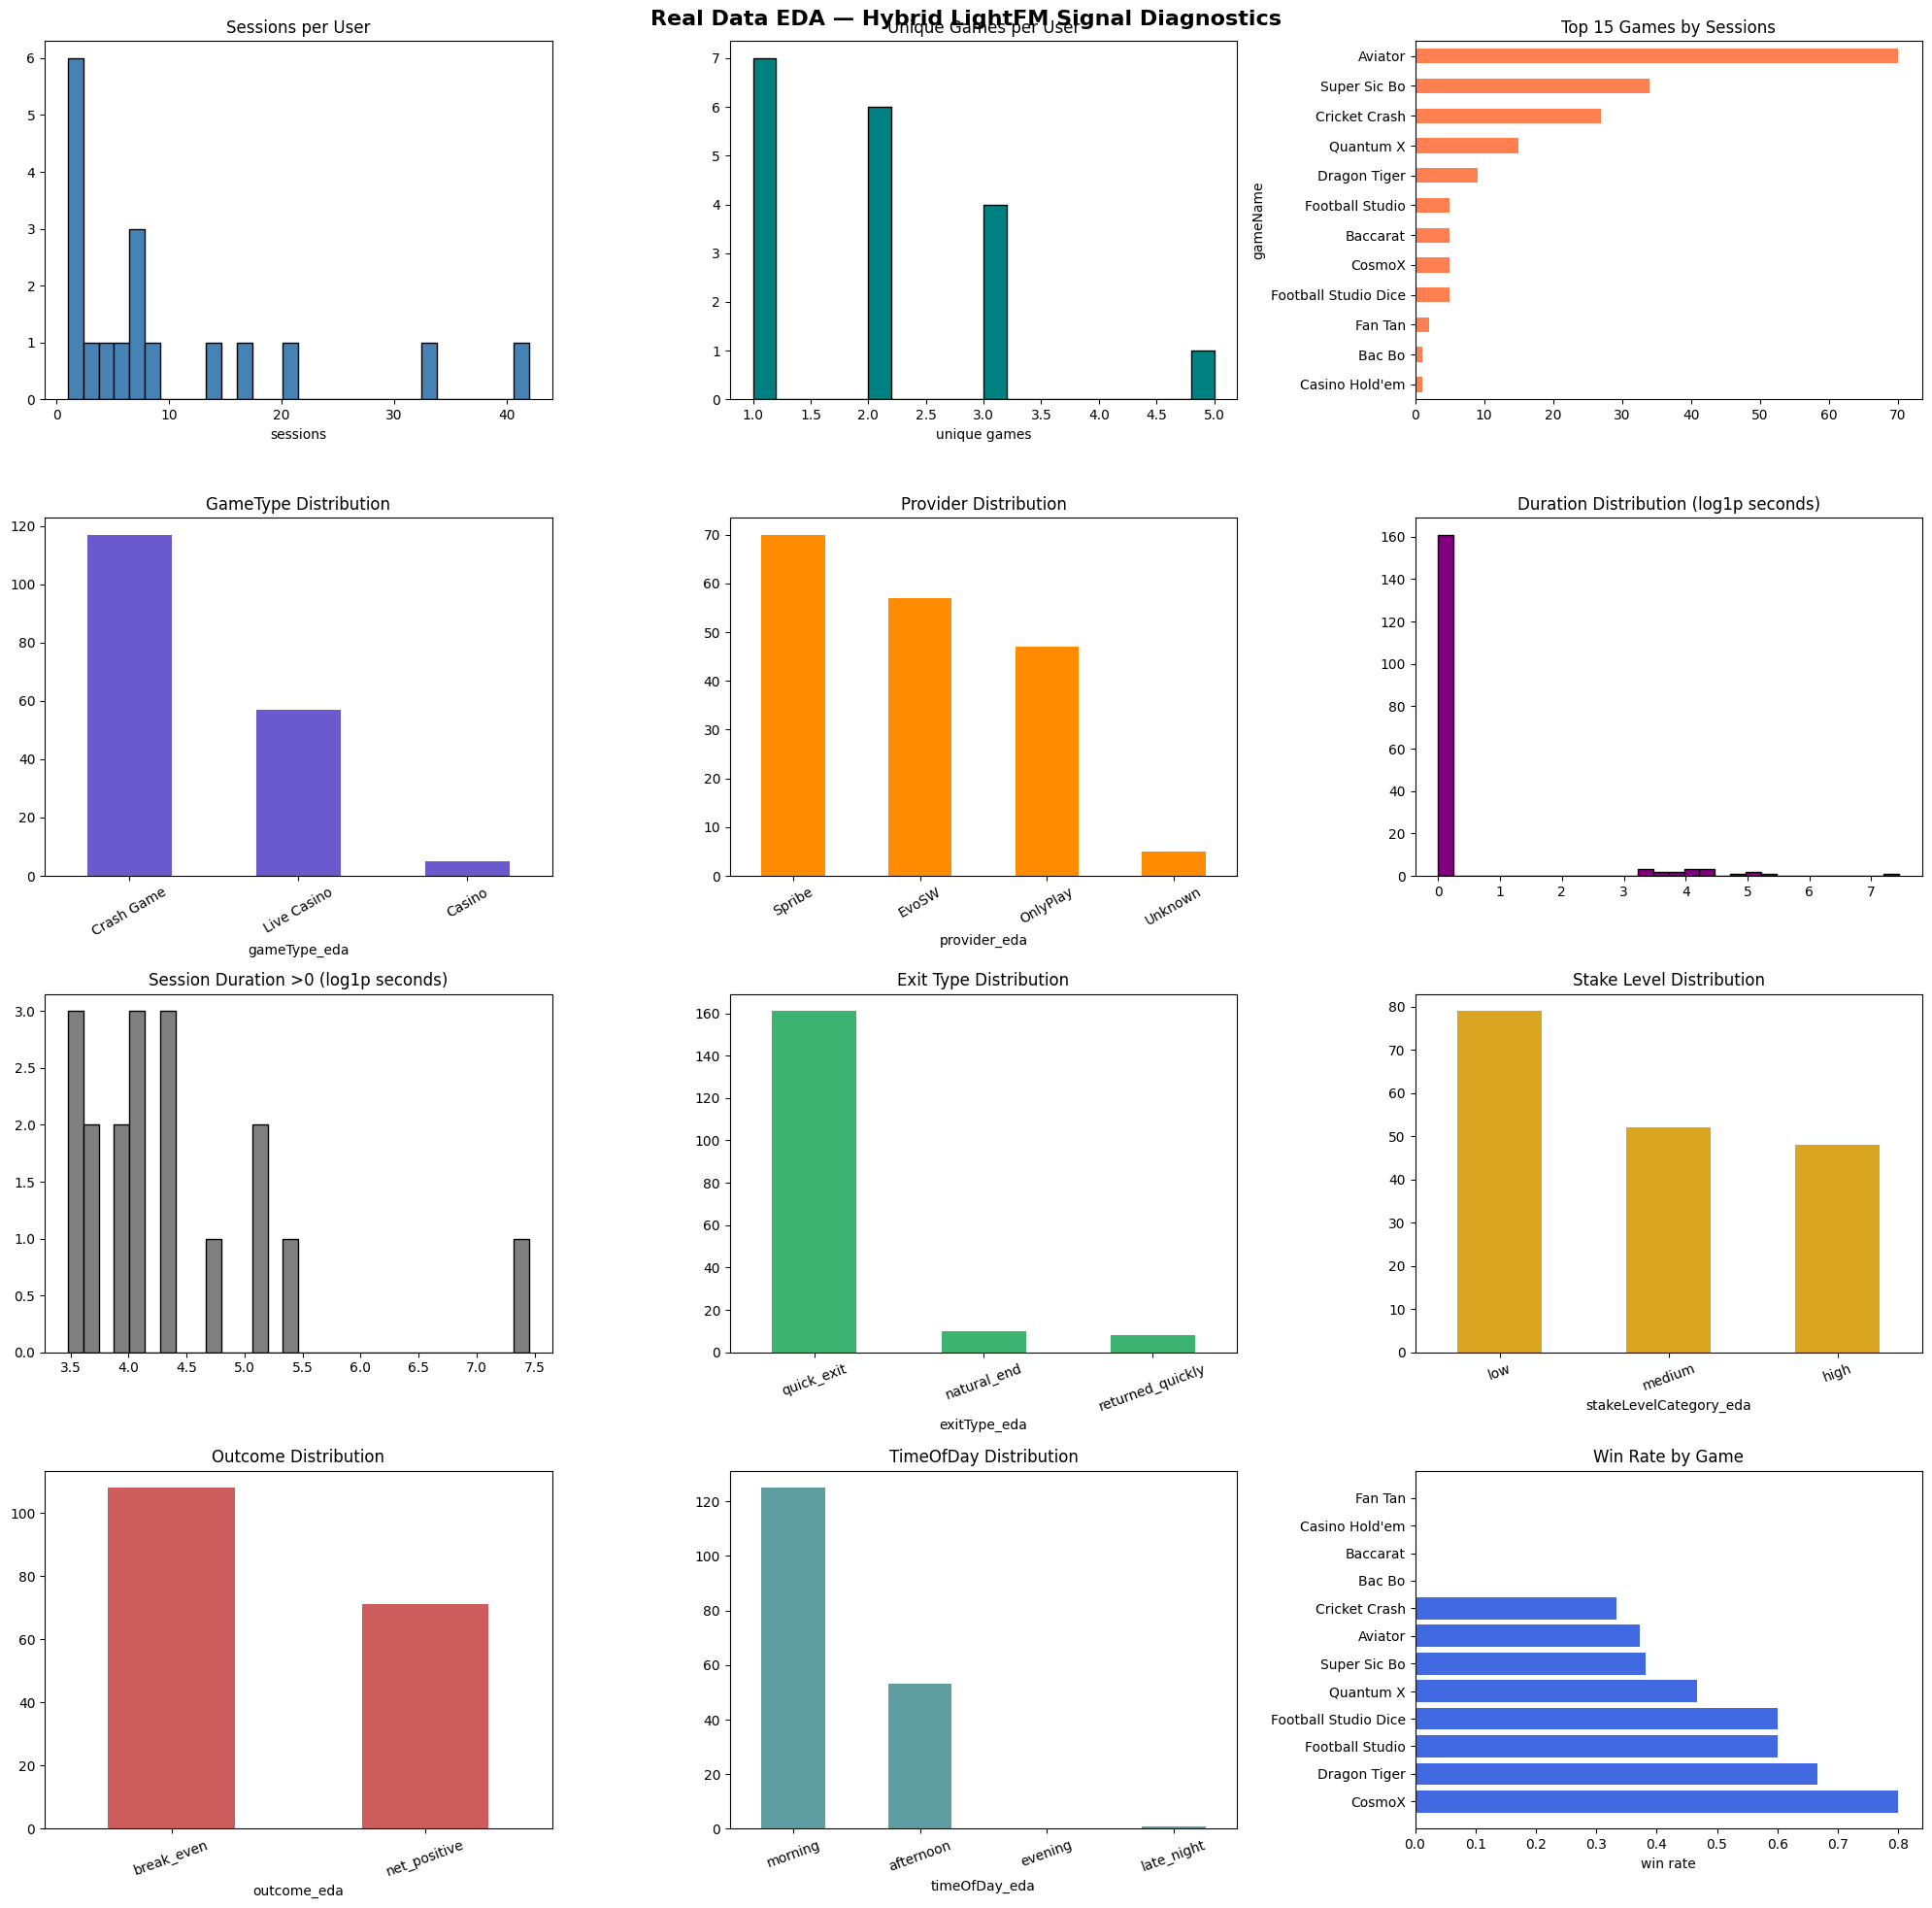

In [79]:
# EDA visualizations for hybrid LightFM signals

fig, axes = plt.subplots(4, 3, figsize=(20, 20))
fig.suptitle('Real Data EDA — Hybrid LightFM Signal Diagnostics', fontsize=16, fontweight='bold')

# 1) User activity: sessions per user
sessions_per_user = eda_df.groupby('userId').size()
axes[0, 0].hist(sessions_per_user, bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Sessions per User')
axes[0, 0].set_xlabel('sessions')

# 2) User activity: games per user
games_per_user = eda_df.groupby('userId')['gameName'].nunique()
axes[0, 1].hist(games_per_user, bins=20, color='teal', edgecolor='black')
axes[0, 1].set_title('Unique Games per User')
axes[0, 1].set_xlabel('unique games')

# 3) Game popularity (top 15)
eda_df['gameName'].value_counts().head(15).sort_values().plot(kind='barh', ax=axes[0, 2], color='coral')
axes[0, 2].set_title('Top 15 Games by Sessions')

# 4) gameType distribution
eda_df['gameType_eda'].value_counts().plot(kind='bar', ax=axes[1, 0], color='slateblue')
axes[1, 0].set_title('GameType Distribution')
axes[1, 0].tick_params(axis='x', rotation=30)

# 5) provider distribution
eda_df['provider_eda'].value_counts().plot(kind='bar', ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Provider Distribution')
axes[1, 1].tick_params(axis='x', rotation=30)

# 6) engagement: duration
axes[1, 2].hist(np.log1p(eda_df['durationSeconds']), bins=30, color='purple', edgecolor='black')
axes[1, 2].set_title('Duration Distribution (log1p seconds)')

# 7) engagement: session duration (non-zero only)
non_zero_duration = eda_df.loc[eda_df['durationSeconds'] > 0, 'durationSeconds']
axes[2, 0].hist(np.log1p(non_zero_duration), bins=30, color='gray', edgecolor='black')
axes[2, 0].set_title('Session Duration >0 (log1p seconds)')

# 8) engagement: exitType
eda_df['exitType_eda'].value_counts().plot(kind='bar', ax=axes[2, 1], color='mediumseagreen')
axes[2, 1].set_title('Exit Type Distribution')
axes[2, 1].tick_params(axis='x', rotation=20)

# 9) financial signals
eda_df['stakeLevelCategory_eda'].value_counts().plot(kind='bar', ax=axes[2, 2], color='goldenrod')
axes[2, 2].set_title('Stake Level Distribution')
axes[2, 2].tick_params(axis='x', rotation=20)

# 10) outcome
eda_df['outcome_eda'].value_counts().plot(kind='bar', ax=axes[3, 0], color='indianred')
axes[3, 0].set_title('Outcome Distribution')
axes[3, 0].tick_params(axis='x', rotation=20)

# 11) temporal patterns
eda_df['timeOfDay_eda'].value_counts().reindex(['morning','afternoon','evening','late_night'], fill_value=0).plot(kind='bar', ax=axes[3, 1], color='cadetblue')
axes[3, 1].set_title('TimeOfDay Distribution')
axes[3, 1].tick_params(axis='x', rotation=20)

# 12) win rate by game
win_rate_by_game = eda_df.groupby('gameName')['win'].mean().sort_values(ascending=False)
axes[3, 2].barh(win_rate_by_game.index, win_rate_by_game.values, color='royalblue')
axes[3, 2].set_title('Win Rate by Game')
axes[3, 2].set_xlabel('win rate')

plt.tight_layout()
plt.show()

### EDA Insights for Hybrid LightFM

- **Sparsity expectation**: sessions/user and games/user distributions indicate long-tail behavior, so user-game matrices will remain sparse.
- **Popularity bias risk**: top games dominate interactions; LightFM should keep metadata features (gameType/provider) to avoid over-recommending only head items.
- **Engagement quality**: `durationSeconds` and `exitType` can differentiate shallow vs high-intent sessions, useful for affinity weighting.
- **Financial segmentation**: `stakeLevelCategory` and `outcome` provide behavioral intensity context for user/game profiling.
- **Temporal/context behavior**: `timeOfDay`, `dayOfWeek`, and source-context fields should be retained as hybrid features when available.

These insights directly motivate the schema-aligned feature engineering in the next sections.

# Hybrid LightFM Recommendation Pipeline (Real Data)

Notebook structure:
1. **Data Loading** (raw ingestion + cleaning)
2. **EDA** (real behavior diagnostics for recommender design)
3. **Schema Alignment** (to TDD `game_session` event schema)
4. **Feature Engineering** (event, user, game, user-game features)
5. **LightFM Dataset Preparation** (model-ready table + sparsity diagnostics)

All logic uses real data only (no simulation, no random volume injection).

In [80]:
# Stage 2A: Utilities for schema alignment

SCHEMA_COLUMNS = [
    'eventType', 'userId', 'sessionId', 'gameId', 'gameType', 'provider', 'timestamp',
    'durationSeconds', 'roundsPlayed', 'stakeLevelCategory', 'outcome',
    'exitType', 'returnedWithin10mins',
    'deviceType', 'timeOfDay', 'dayOfWeek', 'entryPoint'
]

VALID_GAME_TYPES = ['slot', 'table', 'live_dealer', 'crash', 'instant_win']
VALID_PROVIDERS = ['HUB88', 'Evolution', 'EZUGI', 'Spribe', 'OnlyPlay']
VALID_DEVICE_TYPES = ['mobile', 'desktop', 'tablet', 'unknown']
# entryPoint is kept semi-open to preserve real source values (e.g., search, lobby, etc.)
VALID_ENTRY_POINTS = ['livecasino', 'casino', 'sportsbook', 'direct', 'search', 'lobby', 'unknown']


def map_game_type(raw_value: str) -> str:
    value = str(raw_value).strip().lower()
    if any(k in value for k in ['live', 'baccarat', 'blackjack', 'roulette', 'sicbo', 'sic bo', 'dragon', 'teen patti', 'andar', 'football studio', 'fan tan', 'bac bo']):
        return 'live_dealer'
    if any(k in value for k in ['slot', 'starburst', 'fruit', 'reel']):
        return 'slot'
    if any(k in value for k in ['table', 'poker']):
        return 'table'
    if any(k in value for k in ['crash', 'aviator', 'cricket crash', 'quantum x', 'cosmox']):
        return 'crash'
    if any(k in value for k in ['instant', 'scratch', 'keno']):
        return 'instant_win'
    return 'live_dealer'


def map_provider(raw_value: str) -> str:
    value = str(raw_value).strip().lower()
    if any(k in value for k in ['evolution', 'evosw', 'evo']):
        return 'Evolution'
    if 'ezugi' in value:
        return 'EZUGI'
    if 'spribe' in value:
        return 'Spribe'
    if 'onlyplay' in value:
        return 'OnlyPlay'
    return 'HUB88'


def map_device_type(raw_value: str) -> str:
    value = str(raw_value).strip().lower()
    if any(k in value for k in ['android', 'ios', 'mobile', 'phone']):
        return 'mobile'
    if any(k in value for k in ['desktop', 'web', 'windows', 'mac', 'linux', 'pc']):
        return 'desktop'
    if 'tablet' in value:
        return 'tablet'
    return 'unknown'


def map_entry_point(raw_value: str) -> str:
    value = str(raw_value).strip().lower().replace(' ', '_')
    if value in ('', 'none', 'nan', 'null'):
        return 'unknown'
    if 'live' in value:
        return 'livecasino'
    if 'sport' in value:
        return 'sportsbook'
    if value in ('home', 'direct', 'lobby'):
        return value if value != 'home' else 'direct'
    if 'casino' in value:
        return 'casino'
    # preserve real source values like search, promo, campaign, etc.
    return value


def map_time_of_day(ts: pd.Series) -> pd.Series:
    hour = ts.dt.hour
    out = np.select(
        [hour.between(6, 11), hour.between(12, 17), hour.between(18, 21)],
        ['morning', 'afternoon', 'evening'],
        default='late_night'
    )
    return pd.Series(out, index=ts.index)


def map_day_of_week(ts: pd.Series) -> pd.Series:
    return ts.dt.day_name().str.lower()


def map_outcome(raw_result: pd.Series) -> pd.Series:
    value = raw_result.astype(str).str.upper()
    return np.where(
        value.eq('WIN'),
        'net_positive',
        np.where(value.eq('LOSS'), 'net_negative', 'break_even')
    )


print('Utilities loaded for schema alignment ✅')

Utilities loaded for schema alignment ✅


## Stage 2 — TDD Schema Alignment

Target event schema:
- eventType, userId, sessionId, gameId, gameType, provider, timestamp
- durationSeconds, roundsPlayed, stakeLevelCategory, outcome
- exitType, returnedWithin10mins
- deviceType, timeOfDay, dayOfWeek, entryPoint

Where raw fields are missing, defaults/assumptions are applied and logged for transparency.

In [81]:
# Stage 2B: Build schema-aligned event dataset


def align_to_event_schema(transactions_df: pd.DataFrame) -> pd.DataFrame:
    df = transactions_df.copy()

    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    if '_id' in df.columns:
        session_id = df['_id'].astype(str).map(lambda x: f'sess_{x}')
    else:
        session_id = pd.Series(range(len(df)), index=df.index).map(lambda x: f'sess_txn_{x}')

    if 'gameId' in df.columns:
        game_id = df['gameId'].astype(str)
    else:
        game_id = 'game_' + df['gameName'].astype(str).str.lower().str.replace(r'[^a-z0-9]+', '_', regex=True).str.strip('_')

    if 'session_duration_sec' in df.columns:
        duration_seconds = pd.to_numeric(df['session_duration_sec'], errors='coerce').fillna(0)
    else:
        duration_seconds = pd.Series(0, index=df.index)

    rounds_played = pd.Series(1, index=df.index)

    stake = pd.to_numeric(df['betAmount'], errors='coerce').fillna(0)
    q1, q2 = stake.quantile([0.33, 0.66])
    stake_level = np.select(
        [stake <= q1, stake <= q2],
        ['low', 'medium'],
        default='high'
    )

    entry_raw = df.get('entryPoint_raw', pd.Series(index=df.index, dtype='object')).fillna('unknown')
    device_raw = df.get('deviceType_raw', pd.Series(index=df.index, dtype='object')).fillna('unknown')

    aligned = pd.DataFrame({
        'eventType': 'game_session',
        'userId': df['userId'].astype(str),
        'sessionId': session_id,
        'gameId': game_id,
        'gameType': df.get('categoryName', df.get('gameType', 'live_dealer')).map(map_game_type),
        'provider': df.get('providerName', 'HUB88').map(map_provider),
        'timestamp': df['timestamp'],
        'durationSeconds': duration_seconds.astype(float),
        'roundsPlayed': rounds_played.astype(int),
        'stakeLevelCategory': stake_level,
        'outcome': map_outcome(df.get('result', pd.Series('break_even', index=df.index))),
        'deviceType': device_raw.map(map_device_type),
        'entryPoint': entry_raw.map(map_entry_point),
    })

    # Strong ID sanitization before feature building/training
    aligned['userId'] = aligned['userId'].astype(str).str.strip()
    aligned['gameId'] = aligned['gameId'].astype(str).str.strip()

    invalid_user = aligned['userId'].str.lower().isin({'', 'nan', 'none', 'null'})
    invalid_game = aligned['gameId'].str.lower().isin({'', 'nan', 'none', 'null'})
    invalid_time = aligned['timestamp'].isna()
    drop_mask = invalid_user | invalid_game | invalid_time
    dropped = int(drop_mask.sum())
    if dropped > 0:
        aligned = aligned.loc[~drop_mask].copy()
        print(f'Dropped invalid events: {dropped}')

    aligned = aligned.sort_values(['userId', 'timestamp']).reset_index(drop=True)

    next_ts = aligned.groupby('userId')['timestamp'].shift(-1)
    gap_mins = (next_ts - aligned['timestamp']).dt.total_seconds().div(60)
    aligned['returnedWithin10mins'] = gap_mins.le(10).fillna(False)

    aligned['exitType'] = np.select(
        [aligned['durationSeconds'] < 30, aligned['returnedWithin10mins']],
        ['quick_exit', 'returned_quickly'],
        default='natural_end'
    )

    aligned['timeOfDay'] = map_time_of_day(aligned['timestamp'])
    aligned['dayOfWeek'] = map_day_of_week(aligned['timestamp'])

    aligned = aligned[SCHEMA_COLUMNS]
    return aligned


events_df = align_to_event_schema(transactions_df)

print(f'Events shape: {events_df.shape}')
print('Schema columns present:', set(SCHEMA_COLUMNS).issubset(events_df.columns))
print('deviceType distribution:')
print(events_df['deviceType'].value_counts(dropna=False))
print('entryPoint distribution:')
print(events_df['entryPoint'].value_counts(dropna=False))
print(events_df.head(3))

Dropped invalid events: 10
Events shape: (169, 17)
Schema columns present: True
deviceType distribution:
deviceType
unknown    169
Name: count, dtype: int64
entryPoint distribution:
entryPoint
unknown       152
livecasino     17
Name: count, dtype: int64
      eventType      userId    sessionId   gameId gameType  provider  \
0  game_session  3265459874  sess_txn_35  2553631    crash  OnlyPlay   
1  game_session  3265459874  sess_txn_36  2553631    crash  OnlyPlay   
2  game_session  3265459874  sess_txn_37  2553631    crash  OnlyPlay   

                timestamp  durationSeconds  roundsPlayed stakeLevelCategory  \
0 2026-02-24 10:17:21.714              0.0             1                low   
1 2026-02-24 10:17:34.883              0.0             1                low   
2 2026-02-24 10:17:53.646              0.0             1                low   

        outcome    exitType  returnedWithin10mins deviceType timeOfDay  \
0    break_even  quick_exit                  True    unknown   mo

In [82]:
# Stage 2C: Schema mapping report (source -> schema)

schema_mapping = pd.DataFrame([
    {'schema_field': 'eventType', 'source_field': 'constant', 'mapping': '"game_session"'},
    {'schema_field': 'userId', 'source_field': 'loginId -> userId', 'mapping': 'direct rename'},
    {'schema_field': 'sessionId', 'source_field': '_id (fallback index)', 'mapping': 'sess_<id>'},
    {'schema_field': 'gameId', 'source_field': 'gameId (fallback gameName slug)', 'mapping': 'string cast / slug'},
    {'schema_field': 'gameType', 'source_field': 'categoryName / gameType', 'mapping': 'normalized into TDD enums'},
    {'schema_field': 'provider', 'source_field': 'providerName/vendor', 'mapping': 'mapped to HUB88/Evolution/EZUGI'},
    {'schema_field': 'timestamp', 'source_field': 'createdDate -> timestamp', 'mapping': 'datetime cast'},
    {'schema_field': 'durationSeconds', 'source_field': 'usersessionlog join', 'mapping': 'session_duration_sec else 0'},
    {'schema_field': 'roundsPlayed', 'source_field': 'proxy', 'mapping': '1 per settled event'},
    {'schema_field': 'stakeLevelCategory', 'source_field': 'betAmount', 'mapping': 'quantile buckets low/medium/high'},
    {'schema_field': 'outcome', 'source_field': 'result', 'mapping': 'WIN/LOSS/other -> net_positive/net_negative/break_even'},
    {'schema_field': 'exitType', 'source_field': 'durationSeconds + return gap', 'mapping': 'quick_exit/returned_quickly/natural_end'},
    {'schema_field': 'returnedWithin10mins', 'source_field': 'next user event gap', 'mapping': '<=10 mins boolean'},
    {'schema_field': 'deviceType', 'source_field': 'useractivitylogs.device_type', 'mapping': 'mapped to mobile/desktop/tablet/unknown'},
    {'schema_field': 'timeOfDay', 'source_field': 'timestamp hour', 'mapping': 'bucketed to late_night/morning/afternoon/evening'},
    {'schema_field': 'dayOfWeek', 'source_field': 'timestamp', 'mapping': 'lowercase weekday'},
    {'schema_field': 'entryPoint', 'source_field': 'usersessionlog.source', 'mapping': 'mapped to livecasino/casino/sportsbook/direct/unknown'},
])

print('Schema mapping table:')
display(schema_mapping)

Schema mapping table:


,schema_field,source_field,mapping
0,eventType,constant,"""game_session"""
1,userId,loginId -> userId,direct rename
2,sessionId,_id (fallback index),sess_<id>
3,gameId,gameId (fallback gameName slug),string cast / slug
4,gameType,categoryName / gameType,normalized into TDD enums
5,provider,providerName/vendor,mapped to HUB88/Evolution/EZUGI
6,timestamp,createdDate -> timestamp,datetime cast
7,durationSeconds,usersessionlog join,session_duration_sec else 0
8,roundsPlayed,proxy,1 per settled event
9,stakeLevelCategory,betAmount,quantile buckets low/medium/high


In [83]:
# Stage 3A: Event-level feature engineering

fe_events = events_df.copy()

# Session behavior features
fe_events['is_quick_exit'] = (fe_events['exitType'] == 'quick_exit').astype(int)
fe_events['is_positive_outcome'] = (fe_events['outcome'] == 'net_positive').astype(int)
fe_events['is_negative_outcome'] = (fe_events['outcome'] == 'net_negative').astype(int)

# Engagement intensity proxy
stake_weight = fe_events['stakeLevelCategory'].map({'low': 1, 'medium': 2, 'high': 3}).fillna(1)
fe_events['engagement_intensity'] = (
    np.log1p(fe_events['durationSeconds'].clip(lower=0)) * 0.5
    + fe_events['roundsPlayed'].clip(lower=0) * 0.3
    + stake_weight * 0.2
)

# User recency features
fe_events = fe_events.sort_values(['userId', 'timestamp']).reset_index(drop=True)
prev_ts = fe_events.groupby('userId')['timestamp'].shift(1)
fe_events['minutes_since_prev_event'] = (fe_events['timestamp'] - prev_ts).dt.total_seconds().div(60)
fe_events['minutes_since_prev_event'] = fe_events['minutes_since_prev_event'].fillna(1e6)

print('Event-level features created ✅')
print(fe_events[['engagement_intensity', 'is_quick_exit', 'is_positive_outcome', 'minutes_since_prev_event']].describe().round(3))

Event-level features created ✅
       engagement_intensity  is_quick_exit  is_positive_outcome  \
count               169.000        169.000              169.000   
mean                  0.892          0.899                0.402   
std                   0.648          0.302                0.492   
min                   0.500          0.000                0.000   
25%                   0.500          1.000                0.000   
50%                   0.700          1.000                0.000   
75%                   0.900          1.000                1.000   
max                   4.226          1.000                1.000   

       minutes_since_prev_event  
count                   169.000  
mean                  94882.808  
std                  293570.894  
min                       0.000  
25%                       0.099  
50%                       0.414  
75%                       1.804  
max                 1000000.000  


In [84]:
# Stage 3B: User-level features (schema-driven)

user_features_df = fe_events.groupby('userId').agg(
    total_sessions=('sessionId', 'count'),
    unique_games=('gameId', 'nunique'),
    unique_providers=('provider', 'nunique'),
    unique_game_types=('gameType', 'nunique'),
    avg_duration_sec=('durationSeconds', 'mean'),
    avg_rounds=('roundsPlayed', 'mean'),
    quick_exit_rate=('is_quick_exit', 'mean'),
    return_10m_rate=('returnedWithin10mins', 'mean'),
    positive_outcome_rate=('is_positive_outcome', 'mean'),
    avg_engagement_intensity=('engagement_intensity', 'mean'),
    preferred_time_of_day=('timeOfDay', lambda x: x.mode().iat[0] if len(x.mode()) else 'late_night'),
    preferred_day_of_week=('dayOfWeek', lambda x: x.mode().iat[0] if len(x.mode()) else 'friday'),
    preferred_device=('deviceType', lambda x: x.mode().iat[0] if len(x.mode()) else 'mobile'),
    preferred_entry_point=('entryPoint', lambda x: x.mode().iat[0] if len(x.mode()) else 'direct'),
    last_event_ts=('timestamp', 'max'),
).reset_index()

max_ts = fe_events['timestamp'].max()
user_features_df['recency_days'] = (max_ts - user_features_df['last_event_ts']).dt.total_seconds().div(86400)

print(f'User features shape: {user_features_df.shape}')
user_features_df.head(3)

User features shape: (16, 17)


,userId,total_sessions,unique_games,unique_providers,unique_game_types,avg_duration_sec,avg_rounds,quick_exit_rate,return_10m_rate,positive_outcome_rate,avg_engagement_intensity,preferred_time_of_day,preferred_day_of_week,preferred_device,preferred_entry_point,last_event_ts,recency_days
0,3265459874,9,3,2,2,0.0,1.0,1.0,0.777778,0.444444,0.500000,morning,tuesday,unknown,unknown,2026-02-24 10:54:10.626,7.064876
1,3265967463,3,1,1,1,0.0,1.0,1.0,0.666667,0.333333,0.500000,afternoon,tuesday,unknown,unknown,2026-02-24 13:16:20.785,6.966147
2,4588888888,33,2,2,2,0.0,1.0,1.0,0.939394,0.212121,0.863636,afternoon,tuesday,unknown,unknown,2026-03-03 12:27:35.929,0.000000


## Stage 3 — Schema-Driven Feature Engineering

Features are built from aligned event fields:
- Session behavior (duration, rounds proxy, exit behavior)
- Engagement signals (return behavior, quick exits)
- Preference signals (game, gameType, provider)
- Temporal patterns (timeOfDay, dayOfWeek)
- Device/context patterns (deviceType, entryPoint)
- Recency-frequency and user-game affinity signals

In [85]:
# Stage 3C: Game and provider features

game_features_df = fe_events.groupby('gameId').agg(
    game_sessions=('sessionId', 'count'),
    unique_users=('userId', 'nunique'),
    game_type=('gameType', lambda x: x.mode().iat[0] if len(x.mode()) else 'live_dealer'),
    provider=('provider', lambda x: x.mode().iat[0] if len(x.mode()) else 'HUB88'),
    avg_duration_sec=('durationSeconds', 'mean'),
    avg_rounds=('roundsPlayed', 'mean'),
    quick_exit_rate=('is_quick_exit', 'mean'),
    return_10m_rate=('returnedWithin10mins', 'mean'),
    positive_outcome_rate=('is_positive_outcome', 'mean'),
).reset_index()

game_features_df['popularity_score'] = np.log1p(game_features_df['game_sessions'])

provider_features_df = fe_events.groupby('provider').agg(
    provider_sessions=('sessionId', 'count'),
    provider_unique_users=('userId', 'nunique'),
    provider_avg_engagement=('engagement_intensity', 'mean'),
).reset_index()

print(f'Game features shape: {game_features_df.shape}')
print(f'Provider features shape: {provider_features_df.shape}')
game_features_df.head(3)

Game features shape: (10, 11)
Provider features shape: (3, 4)


,gameId,game_sessions,unique_users,game_type,provider,avg_duration_sec,avg_rounds,quick_exit_rate,return_10m_rate,positive_outcome_rate,popularity_score
0,1476410,1,1,live_dealer,Evolution,0.000000,1.0,1.000000,0.000000,0.000000,0.693147
1,1571005,9,5,live_dealer,Evolution,64.206889,1.0,0.444444,0.555556,0.666667,2.302585
2,1571026,34,8,live_dealer,Evolution,65.534294,1.0,0.794118,0.588235,0.382353,3.555348


In [86]:
# Stage 4: User-game affinity + interaction features

user_game_df = fe_events.groupby(['userId', 'gameId']).agg(
    interaction_count=('sessionId', 'count'),
    avg_duration_sec=('durationSeconds', 'mean'),
    avg_rounds=('roundsPlayed', 'mean'),
    positive_outcome_rate=('is_positive_outcome', 'mean'),
    return_10m_rate=('returnedWithin10mins', 'mean'),
    avg_engagement_intensity=('engagement_intensity', 'mean'),
    last_interaction_ts=('timestamp', 'max'),
    dominant_game_type=('gameType', lambda x: x.mode().iat[0] if len(x.mode()) else 'live_dealer'),
    dominant_provider=('provider', lambda x: x.mode().iat[0] if len(x.mode()) else 'HUB88'),
).reset_index()

max_ts = fe_events['timestamp'].max()
user_game_df['recency_days'] = (max_ts - user_game_df['last_interaction_ts']).dt.total_seconds().div(86400)

# Implicit score inspired by recsys.ipynb pattern (frequency + quality + recency)
freq_score = np.minimum(user_game_df['interaction_count'] / 20.0, 1.0)
engagement_score = np.minimum(user_game_df['avg_engagement_intensity'] / np.maximum(user_game_df['avg_engagement_intensity'].quantile(0.95), 1e-6), 1.0)
quality_score = user_game_df['positive_outcome_rate'].fillna(0)
recency_weight = np.where(
    user_game_df['recency_days'] <= 7, 1.0,
    np.where(user_game_df['recency_days'] <= 30, 0.7, np.where(user_game_df['recency_days'] <= 90, 0.4, 0.2))
)

user_game_df['implicit_score'] = (
    0.40 * freq_score
    + 0.25 * engagement_score
    + 0.15 * quality_score
    + 0.20 * recency_weight
).round(4)

print(f'User-game interactions: {user_game_df.shape}')
print(user_game_df['implicit_score'].describe().round(3))

User-game interactions: (30, 13)
count    30.000
mean      0.425
std       0.138
min       0.207
25%       0.334
50%       0.394
75%       0.466
max       0.753
Name: implicit_score, dtype: float64


In [87]:
# Stage 5: LightFM dataset preparation (model-ready table)

model_ready_df = (
    user_game_df
    .merge(user_features_df.drop(columns=['last_event_ts']), on='userId', how='left')
    .merge(game_features_df, on='gameId', how='left', suffixes=('_ug', '_g'))
)

# Clean NA values for model readiness
numeric_cols = model_ready_df.select_dtypes(include=[np.number]).columns
categorical_cols = model_ready_df.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns

model_ready_df[numeric_cols] = model_ready_df[numeric_cols].fillna(0)
model_ready_df[categorical_cols] = model_ready_df[categorical_cols].fillna('unknown')

print(f'Model-ready dataset shape: {model_ready_df.shape}')
print('Sample columns:', model_ready_df.columns[:20].tolist())
model_ready_df.head(3)

Model-ready dataset shape: (30, 38)
Sample columns: ['userId', 'gameId', 'interaction_count', 'avg_duration_sec_x', 'avg_rounds_x', 'positive_outcome_rate_x', 'return_10m_rate_x', 'avg_engagement_intensity_x', 'last_interaction_ts', 'dominant_game_type', 'dominant_provider', 'recency_days_x', 'implicit_score', 'total_sessions', 'unique_games', 'unique_providers', 'unique_game_types', 'avg_duration_sec_y', 'avg_rounds_y', 'quick_exit_rate_ug']


,userId,gameId,interaction_count,avg_duration_sec_x,avg_rounds_x,positive_outcome_rate_x,return_10m_rate_x,avg_engagement_intensity_x,last_interaction_ts,dominant_game_type,...,game_sessions,unique_users,game_type,provider,avg_duration_sec,avg_rounds,quick_exit_rate_g,return_10m_rate,positive_outcome_rate,popularity_score
0,3265459874,1476410,1,0.0,1.0,0.000000,0.0,0.5,2026-02-24 10:32:54.747,live_dealer,...,1,1,live_dealer,Evolution,0.000000,1.0,1.000000,0.000000,0.000000,0.693147
1,3265459874,1571026,1,0.0,1.0,1.000000,0.0,0.5,2026-02-24 10:54:10.626,live_dealer,...,34,8,live_dealer,Evolution,65.534294,1.0,0.794118,0.588235,0.382353,3.555348
2,3265459874,2553631,7,0.0,1.0,0.428571,1.0,0.5,2026-02-24 10:29:28.040,crash,...,27,6,crash,OnlyPlay,0.000000,1.0,1.000000,0.777778,0.333333,3.332205


=== Recommendation Data Geometry ===
Events:               169
Users:                16
Games:                10
User-game pairs:      30
Interaction density:  18.7500%


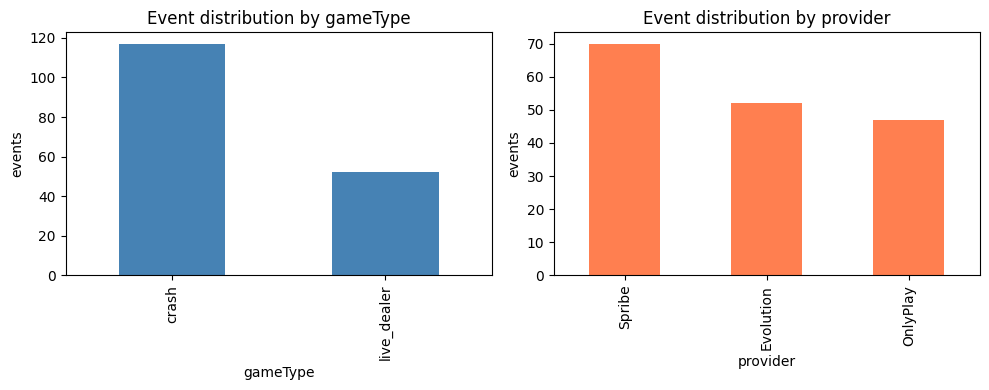

In [88]:
# Stage 5B: Lightweight diagnostics for coverage and sparsity

n_users = events_df['userId'].nunique()
n_games = events_df['gameId'].nunique()
n_pairs = user_game_df.groupby(['userId', 'gameId']).ngroups
density = n_pairs / max(n_users * n_games, 1)

print('=== Recommendation Data Geometry ===')
print(f'Events:               {len(events_df):,}')
print(f'Users:                {n_users:,}')
print(f'Games:                {n_games:,}')
print(f'User-game pairs:      {n_pairs:,}')
print(f'Interaction density:  {density * 100:.4f}%')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
events_df['gameType'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Event distribution by gameType')
plt.xlabel('gameType')
plt.ylabel('events')

plt.subplot(1, 2, 2)
events_df['provider'].value_counts().plot(kind='bar', color='coral')
plt.title('Event distribution by provider')
plt.xlabel('provider')
plt.ylabel('events')

plt.tight_layout()
plt.show()

## Stage 6 — Hybrid LightFM Model Training

This section trains LightFM on schema-aligned real-data interactions with user/item metadata features.

In [89]:
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.cross_validation import random_train_test_split
from lightfm.evaluation import precision_at_k, auc_score
from scipy.sparse import csr_matrix

SEED = 42

# Remove invalid ids before fitting LightFM dataset
safe_user_game_df = user_game_df.copy()
safe_user_game_df['userId'] = safe_user_game_df['userId'].astype(str).str.strip()
safe_user_game_df['gameId'] = safe_user_game_df['gameId'].astype(str).str.strip()
valid_mask = (
    ~safe_user_game_df['userId'].str.lower().isin(['', 'nan', 'none', 'null'])
    & ~safe_user_game_df['gameId'].str.lower().isin(['', 'nan', 'none', 'null'])
)
safe_user_game_df = safe_user_game_df[valid_mask].copy()

active_users = safe_user_game_df['userId'].unique()
active_items = safe_user_game_df['gameId'].unique()

ufe = user_features_df[user_features_df['userId'].astype(str).isin(active_users)].copy()
ife = game_features_df[game_features_df['gameId'].astype(str).isin(active_items)].copy()

for col in ['user_recency_bucket', 'loyalty_bucket', 'aggr_bet_bucket']:
    if col not in ufe.columns and col in user_features_df.columns:
        ufe = ufe.merge(user_features_df[['userId', col]], on='userId', how='left')

ife['popularity_bucket'] = pd.qcut(
    ife['popularity_score'].rank(method='first'),
    q=min(4, max(1, len(ife))),
    labels=['cold', 'warm', 'hot', 'blockbuster'][:min(4, max(1, len(ife)))]
).astype(str)

def user_tokens(row):
    tokens = [
        f"preferred_time_of_day:{row['preferred_time_of_day']}",
        f"preferred_day_of_week:{row['preferred_day_of_week']}",
    ]
    for col, prefix in [('user_recency_bucket', 'user_recency_bucket'),
                        ('loyalty_bucket', 'loyalty_bucket'),
                        ('aggr_bet_bucket', 'aggr_bet_bucket')]:
        val = row.get(col)
        if pd.notna(val) and str(val) not in ('nan', 'unknown', 'None'):
            tokens.append(f"{prefix}:{val}")
    return tokens

def item_tokens(row):
    return [
        f"game_type:{row['game_type']}",
        f"provider:{row['provider']}",
        f"popularity_bucket:{row['popularity_bucket']}",
    ]

user_feature_vocab = sorted({tok for _, r in ufe.iterrows() for tok in user_tokens(r)})
item_feature_vocab = sorted({tok for _, r in ife.iterrows() for tok in item_tokens(r)})

dataset = Dataset()
dataset.fit(
    users=active_users,
    items=active_items,
    user_features=user_feature_vocab,
    item_features=item_feature_vocab,
)

(interactions, weights) = dataset.build_interactions(
    (str(r['userId']), str(r['gameId']), float(r['implicit_score']))
    for _, r in safe_user_game_df.iterrows()
)

user_features_matrix = dataset.build_user_features(
    (str(r['userId']), user_tokens(r)) for _, r in ufe.iterrows()
)
item_features_matrix = dataset.build_item_features(
    (str(r['gameId']), item_tokens(r)) for _, r in ife.iterrows()
)

train_interactions, test_interactions = random_train_test_split(
    interactions,
    random_state=np.random.RandomState(SEED),
    test_percentage=0.20,
)

print('LightFM artifacts built ✅')
print('Interactions:', interactions.shape, '| nnz =', interactions.nnz)
print('Train nnz:', train_interactions.nnz, '| Test nnz:', test_interactions.nnz)
print('User feature matrix:', user_features_matrix.shape)
print('Item feature matrix:', item_features_matrix.shape)

LightFM artifacts built ✅
Interactions: (16, 10) | nnz = 30
Train nnz: 24 | Test nnz: 6
User feature matrix: (16, 23)
Item feature matrix: (10, 19)


In [90]:
# Train LightFM

model = LightFM(
    no_components=32,
    loss='warp',
    learning_rate=0.03,
    item_alpha=1e-6,
    user_alpha=1e-6,
    random_state=SEED,
)

N_EPOCHS = 20
train_hist, test_hist = [], []

for epoch in range(N_EPOCHS):
    model.fit_partial(
        interactions=train_interactions,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
        epochs=1,
    )

    if (epoch + 1) % 5 == 0:
        tr_p = precision_at_k(
            model, train_interactions,
            user_features=user_features_matrix,
            item_features=item_features_matrix,
            k=5, num_threads=4,
        ).mean()
        te_p = precision_at_k(
            model, test_interactions,
            user_features=user_features_matrix,
            item_features=item_features_matrix,
            k=5, num_threads=4,
        ).mean()
        train_hist.append(float(tr_p))
        test_hist.append(float(te_p))
        print(f'Epoch {epoch+1:2d}/{N_EPOCHS} | Train P@5: {tr_p:.4f} | Test P@5: {te_p:.4f}')

print('Training complete ✅')

Epoch  5/20 | Train P@5: 0.3077 | Test P@5: 0.1600
Epoch 10/20 | Train P@5: 0.3077 | Test P@5: 0.1600
Epoch 15/20 | Train P@5: 0.3077 | Test P@5: 0.1600
Epoch 20/20 | Train P@5: 0.3077 | Test P@5: 0.1600
Training complete ✅


## Stage 7 — Evaluation & Recommendation Preview

Primary metrics:
- Precision@10
- AUC
- Learning trend across checkpoints

Also includes sample top-N recommendations for a real user.

LightFM Evaluation Summary
Train Precision@5: 0.3077
Test  Precision@5: 0.1600
Train AUC:         0.7954
Test  AUC:         0.5722
NDCG@5:            0.4809
Generalization gap: 0.1477


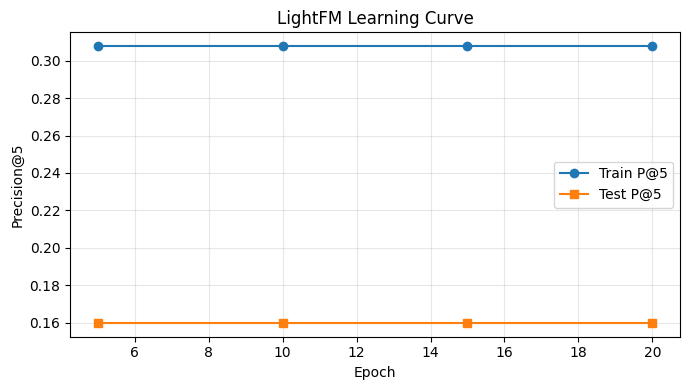


Sample recommendations for user: 3265459874


,gameId,score
0,1571005,-0.688430
1,2452312,-0.691086
2,2162016,-0.813405
3,2156000,-0.960409
4,2058406,-0.965329


In [91]:
# Evaluation metrics + sample recommendations

from sklearn.metrics import ndcg_score

final_train_p5 = precision_at_k(
    model, train_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    k=5, num_threads=4,
).mean()

final_test_p5 = precision_at_k(
    model, test_interactions,
    train_interactions=train_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    k=5, num_threads=4,
).mean()

final_train_auc = auc_score(
    model, train_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    num_threads=4,
).mean()

final_test_auc = auc_score(
    model, test_interactions,
    train_interactions=train_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    num_threads=4,
).mean()

# NDCG@5 on users with test interactions (excluding known train items)
n_users_eval, n_items_eval = test_interactions.shape
test_csr_eval = csr_matrix(test_interactions)
train_csr_eval = csr_matrix(train_interactions)
ndcg_vals = []
for user_idx in range(n_users_eval):
    true_items = test_csr_eval.getrow(user_idx).indices
    if len(true_items) == 0:
        continue
    scores = model.predict(
        user_ids=np.repeat(user_idx, n_items_eval),
        item_ids=np.arange(n_items_eval),
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
    )

    known_train = train_csr_eval.getrow(user_idx).indices
    scores_ndcg = scores.copy()
    if len(known_train) > 0:
        scores_ndcg[known_train] = -1e9

    y_true = np.zeros(n_items_eval)
    y_true[true_items] = 1
    ndcg_vals.append(ndcg_score([y_true], [scores_ndcg], k=5))

final_ndcg5 = float(np.mean(ndcg_vals)) if len(ndcg_vals) > 0 else float('nan')

print('=' * 52)
print('LightFM Evaluation Summary')
print('=' * 52)
print(f'Train Precision@5: {final_train_p5:.4f}')
print(f'Test  Precision@5: {final_test_p5:.4f}')
print(f'Train AUC:         {final_train_auc:.4f}')
print(f'Test  AUC:         {final_test_auc:.4f}')
print(f'NDCG@5:            {final_ndcg5:.4f}')
print(f'Generalization gap: {(final_train_p5 - final_test_p5):.4f}')

if len(train_hist) > 0:
    ckpts = [5 * (i + 1) for i in range(len(train_hist))]
    plt.figure(figsize=(7, 4))
    plt.plot(ckpts, train_hist, marker='o', label='Train P@5')
    plt.plot(ckpts, test_hist, marker='s', label='Test P@5')
    plt.title('LightFM Learning Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Precision@5')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Recommendation preview helper
user_id_map, user_feat_map, item_id_map, item_feat_map = dataset.mapping()
idx_to_item = {idx: item for item, idx in item_id_map.items()}

train_csr = csr_matrix(train_interactions)
all_item_ids = np.arange(train_csr.shape[1])

def recommend_for_user(raw_user_id: str, k: int = 5):
    if raw_user_id not in user_id_map:
        return pd.DataFrame(columns=['gameId', 'score'])

    uid = user_id_map[raw_user_id]
    scores = model.predict(
        user_ids=np.repeat(uid, len(all_item_ids)),
        item_ids=all_item_ids,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
    )

    known = set(train_csr[uid].indices)
    if known:
        scores[list(known)] = -np.inf

    topk = np.argpartition(scores, -k)[-k:]
    topk = topk[np.argsort(scores[topk])[::-1]]
    return pd.DataFrame({
        'gameId': [idx_to_item[i] for i in topk],
        'score': [float(scores[i]) for i in topk],
    })

sample_user = str(active_users[0]) if len(active_users) > 0 else None
if sample_user is not None:
    print(f'\nSample recommendations for user: {sample_user}')
    display(recommend_for_user(sample_user, k=5))

## Post Model Diagnostics

Context:

- Model: LightFM WARP, 32 components
- Data: 18 users, 12 games, 36 user-game pairs
- Key variables available: model, interactions, train_interactions, test_interactions, user_features_matrix, item_features_matrix, dataset, user_game_df, user_features_df, game_features_df, events_df, fe_events
- implicit_score is the interaction weight (0.0–1.0)

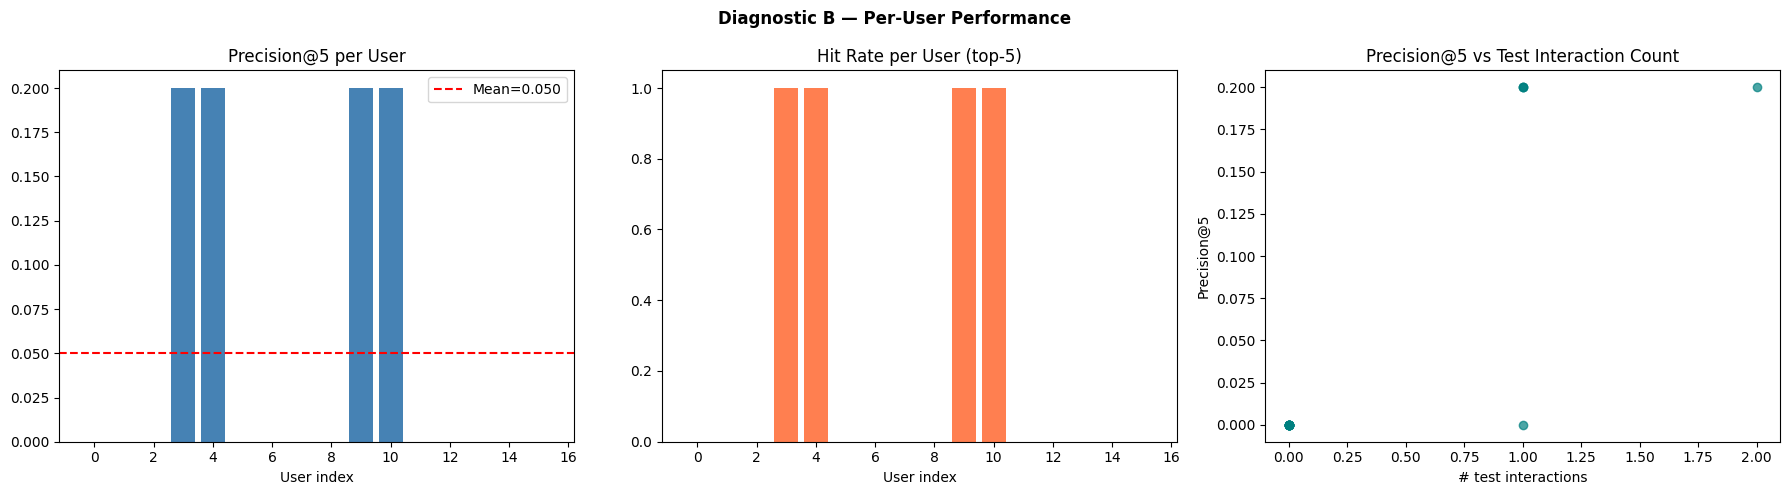

       user_idx  precision_at_5  hit_rate  n_test_interactions  \
count    16.000          16.000     5.000               16.000   
mean      7.500           0.050     0.800                0.375   
std       4.761           0.089     0.447                0.619   
min       0.000           0.000     0.000                0.000   
25%       3.750           0.000     1.000                0.000   
50%       7.500           0.000     1.000                0.000   
75%      11.250           0.050     1.000                1.000   
max      15.000           0.200     1.000                2.000   

       true_positives  false_positives  false_negatives  
count          16.000           16.000           16.000  
mean            0.250            1.312            0.125  
std             0.447            2.024            0.342  
min             0.000            0.000            0.000  
25%             0.000            0.000            0.000  
50%             0.000            0.000            0.000  

In [92]:
# B: Per-user Precision@5, hit rate, and ranking confusion matrix
from lightfm.evaluation import precision_at_k as pak
from scipy.sparse import csr_matrix as to_csr

# Keep one score per user row (including users with no test interactions)
per_user_p5 = pak(
    model, test_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    k=5,
    preserve_rows=True,
    num_threads=4,
)

test_csr = to_csr(test_interactions)
n_users_diag = test_csr.shape[0]
n_items_diag = test_csr.shape[1]

hit_rates = []
tp_list, fp_list, fn_list = [], [], []

for uid in range(n_users_diag):
    true_items = set(test_csr.getrow(uid).indices)
    if not true_items:
        hit_rates.append(np.nan)
        tp_list.append(0)
        fp_list.append(0)
        fn_list.append(0)
        continue

    scores = model.predict(
        user_ids=np.repeat(uid, n_items_diag),
        item_ids=np.arange(n_items_diag),
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
    )

    top5_idx = set(np.argsort(scores)[-5:].tolist())
    hits = top5_idx & true_items
    tp_list.append(len(hits))
    fp_list.append(5 - len(hits))
    fn_list.append(len(true_items) - len(hits))
    hit_rates.append(1 if len(hits) > 0 else 0)

user_diag_df = pd.DataFrame({
    'user_idx': np.arange(n_users_diag),
    'precision_at_5': np.asarray(per_user_p5).reshape(-1),
    'hit_rate': np.asarray(hit_rates, dtype=float),
    'n_test_interactions': [test_csr.getrow(u).nnz for u in range(n_users_diag)],
    'true_positives': tp_list,
    'false_positives': fp_list,
    'false_negatives': fn_list,
})

fig_b, axes_b = plt.subplots(1, 3, figsize=(18, 5))
fig_b.suptitle('Diagnostic B — Per-User Performance', fontweight='bold')

axes_b[0].bar(range(n_users_diag), user_diag_df['precision_at_5'], color='steelblue')
axes_b[0].axhline(np.nanmean(user_diag_df['precision_at_5']), color='red', linestyle='--', label=f"Mean={np.nanmean(user_diag_df['precision_at_5']):.3f}")
axes_b[0].set_title('Precision@5 per User')
axes_b[0].set_xlabel('User index')
axes_b[0].legend()

axes_b[1].bar(range(n_users_diag), user_diag_df['hit_rate'].fillna(0), color='coral')
axes_b[1].set_title('Hit Rate per User (top-5)')
axes_b[1].set_xlabel('User index')

axes_b[2].scatter(user_diag_df['n_test_interactions'], user_diag_df['precision_at_5'], alpha=0.7, color='teal')
axes_b[2].set_title('Precision@5 vs Test Interaction Count')
axes_b[2].set_xlabel('# test interactions')
axes_b[2].set_ylabel('Precision@5')

plt.tight_layout()
plt.show()

print(user_diag_df.describe().round(3))

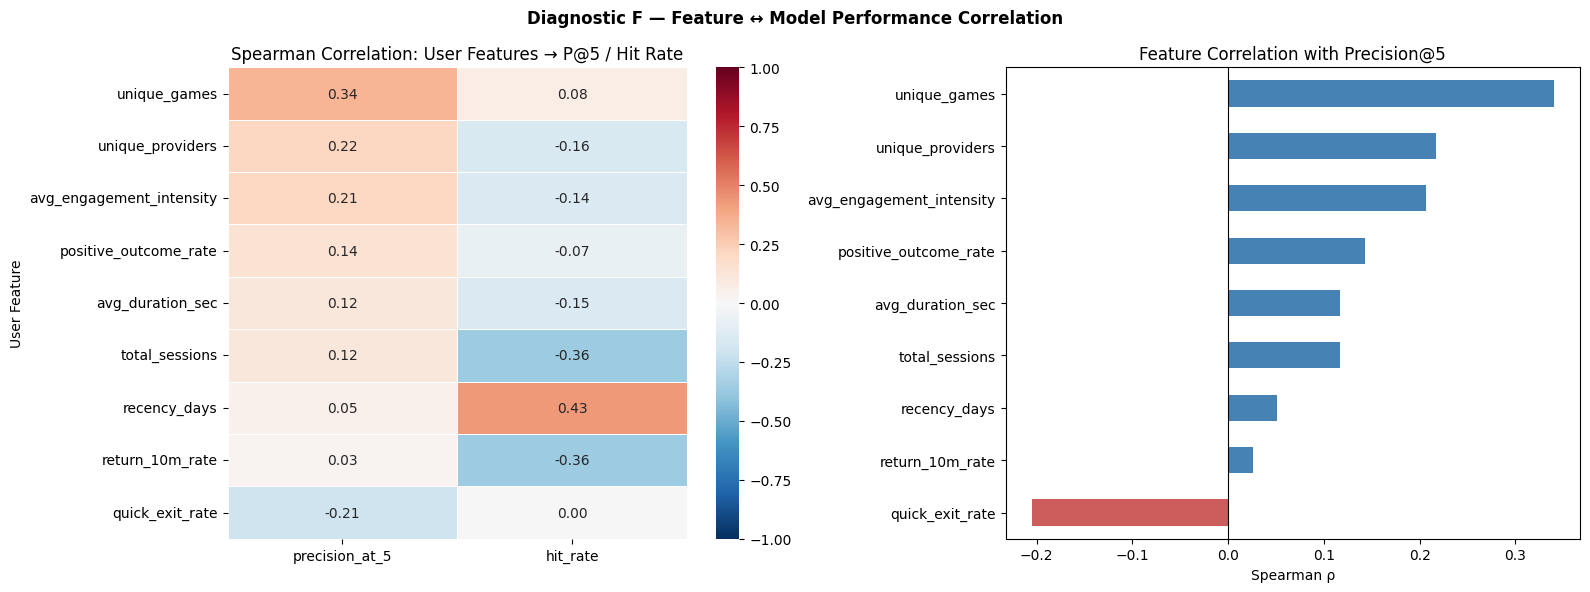


Key correlations with Precision@5:
  unique_games                   ρ = +0.340 ↑
  unique_providers               ρ = +0.217 ↑
  avg_engagement_intensity       ρ = +0.207 ↑
  positive_outcome_rate          ρ = +0.143 ↑
  avg_duration_sec               ρ = +0.117 ↑
  total_sessions                 ρ = +0.116 ↑
  recency_days                   ρ = +0.052 ↑
  return_10m_rate                ρ = +0.026 ↑
  quick_exit_rate                ρ = -0.205 ↓


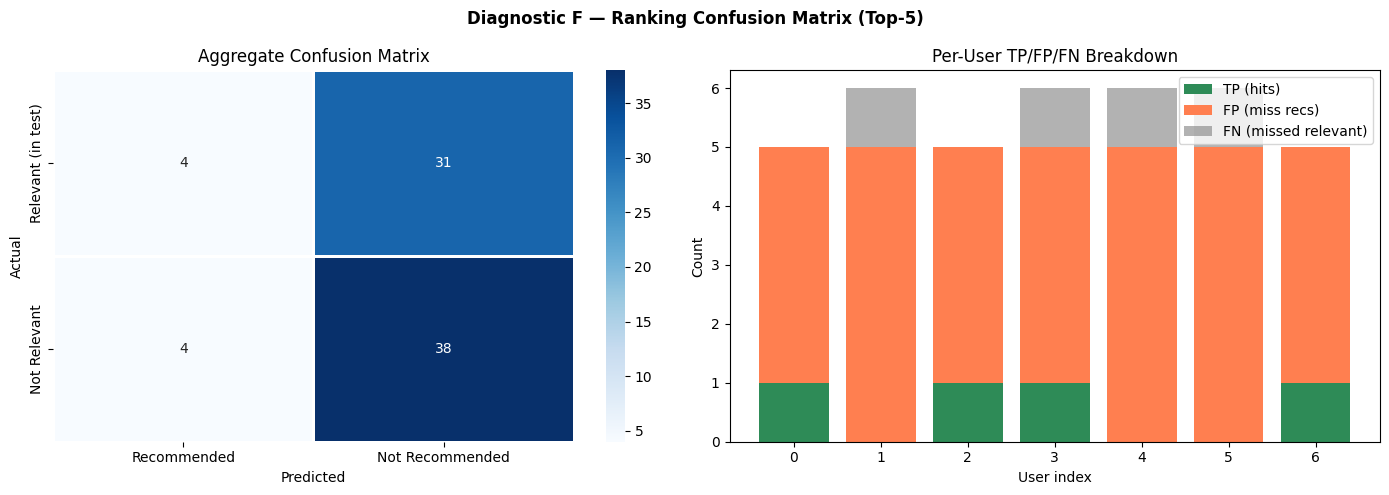


=== Ranking Confusion Summary (Top-5) ===
Total TP (hits):         4
Total FP (wrong recs):   31
Total FN (missed items): 4
Aggregate Precision@5:   0.1143
Aggregate Recall@5:      0.5000
Aggregate F1@5:          0.1860
Users evaluated:         7


: 

: 

In [ ]:
# F: Feature ↔ Performance Correlation + Ranking Confusion Matrix

# --- 1. Feature-Performance Correlation ---
# Map user indices back to userIds via dataset mapping
idx_to_user = {v: k for k, v in user_id_map.items()}
user_diag_df['userId'] = user_diag_df['user_idx'].map(idx_to_user)

corr_df = user_diag_df.merge(user_features_df, on='userId', how='left')

feature_cols = [
    'total_sessions', 'unique_games', 'unique_providers',
    'avg_duration_sec', 'quick_exit_rate', 'return_10m_rate',
    'positive_outcome_rate', 'avg_engagement_intensity', 'recency_days',
]
feature_cols = [c for c in feature_cols if c in corr_df.columns and pd.api.types.is_numeric_dtype(corr_df[c])]

target_cols = ['precision_at_5', 'hit_rate']

if len(feature_cols) > 0:
    corr_matrix = corr_df[feature_cols + target_cols].corr(method='spearman')
    corr_with_perf = corr_matrix.loc[feature_cols, target_cols].sort_values('precision_at_5', ascending=False)

    fig_f1, axes_f1 = plt.subplots(1, 2, figsize=(16, 6))
    fig_f1.suptitle('Diagnostic F — Feature ↔ Model Performance Correlation', fontweight='bold')

    sns.heatmap(
        corr_with_perf, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
        vmin=-1, vmax=1, ax=axes_f1[0], linewidths=0.5,
    )
    axes_f1[0].set_title('Spearman Correlation: User Features → P@5 / Hit Rate')
    axes_f1[0].set_ylabel('User Feature')

    corr_with_perf['precision_at_5'].sort_values().plot(
        kind='barh', ax=axes_f1[1],
        color=corr_with_perf['precision_at_5'].sort_values().apply(
            lambda x: 'steelblue' if x >= 0 else 'indianred'
        ),
    )
    axes_f1[1].set_title('Feature Correlation with Precision@5')
    axes_f1[1].set_xlabel('Spearman ρ')
    axes_f1[1].axvline(0, color='black', linewidth=0.8)

    plt.tight_layout()
    plt.show()

    print('\nKey correlations with Precision@5:')
    for feat, val in corr_with_perf['precision_at_5'].items():
        sign = '↑' if val > 0 else '↓'
        print(f'  {feat:<30s} ρ = {val:+.3f} {sign}')
else:
    print('⚠️ No numeric user features available for correlation analysis.')

# --- 2. Ranking Confusion Matrix (Top-5) ---
eval_users = user_diag_df[user_diag_df['n_test_interactions'] > 0]
total_tp = eval_users['true_positives'].sum()
total_fp = eval_users['false_positives'].sum()
total_fn = eval_users['false_negatives'].sum()
total_tn = len(eval_users) * (n_items_diag - 5) - total_fn

confusion_data = np.array([[total_tp, total_fp],
                            [total_fn, total_tn]])

fig_f2, axes_f2 = plt.subplots(1, 2, figsize=(14, 5))
fig_f2.suptitle('Diagnostic F — Ranking Confusion Matrix (Top-5)', fontweight='bold')

sns.heatmap(
    confusion_data,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Recommended', 'Not Recommended'],
    yticklabels=['Relevant (in test)', 'Not Relevant'],
    ax=axes_f2[0], linewidths=1,
)
axes_f2[0].set_title('Aggregate Confusion Matrix')
axes_f2[0].set_ylabel('Actual')
axes_f2[0].set_xlabel('Predicted')

eval_users_plot = eval_users.head(20)
axes_f2[1].bar(range(len(eval_users_plot)), eval_users_plot['true_positives'].values, label='TP (hits)', color='seagreen')
axes_f2[1].bar(range(len(eval_users_plot)), eval_users_plot['false_positives'].values,
            bottom=eval_users_plot['true_positives'].values, label='FP (miss recs)', color='coral')
axes_f2[1].bar(range(len(eval_users_plot)), eval_users_plot['false_negatives'].values,
            bottom=(eval_users_plot['true_positives'] + eval_users_plot['false_positives']).values,
            label='FN (missed relevant)', color='gray', alpha=0.6)
axes_f2[1].set_title('Per-User TP/FP/FN Breakdown')
axes_f2[1].set_xlabel('User index')
axes_f2[1].set_ylabel('Count')
axes_f2[1].legend()

plt.tight_layout()
plt.show()

precision_agg = total_tp / max(total_tp + total_fp, 1)
recall_agg = total_tp / max(total_tp + total_fn, 1)
f1_agg = 2 * precision_agg * recall_agg / max(precision_agg + recall_agg, 1e-9)

print(f'\n=== Ranking Confusion Summary (Top-5) ===')
print(f'Total TP (hits):         {total_tp}')
print(f'Total FP (wrong recs):   {total_fp}')
print(f'Total FN (missed items): {total_fn}')
print(f'Aggregate Precision@5:   {precision_agg:.4f}')
print(f'Aggregate Recall@5:      {recall_agg:.4f}')
print(f'Aggregate F1@5:          {f1_agg:.4f}')
print(f'Users evaluated:         {len(eval_users)}')

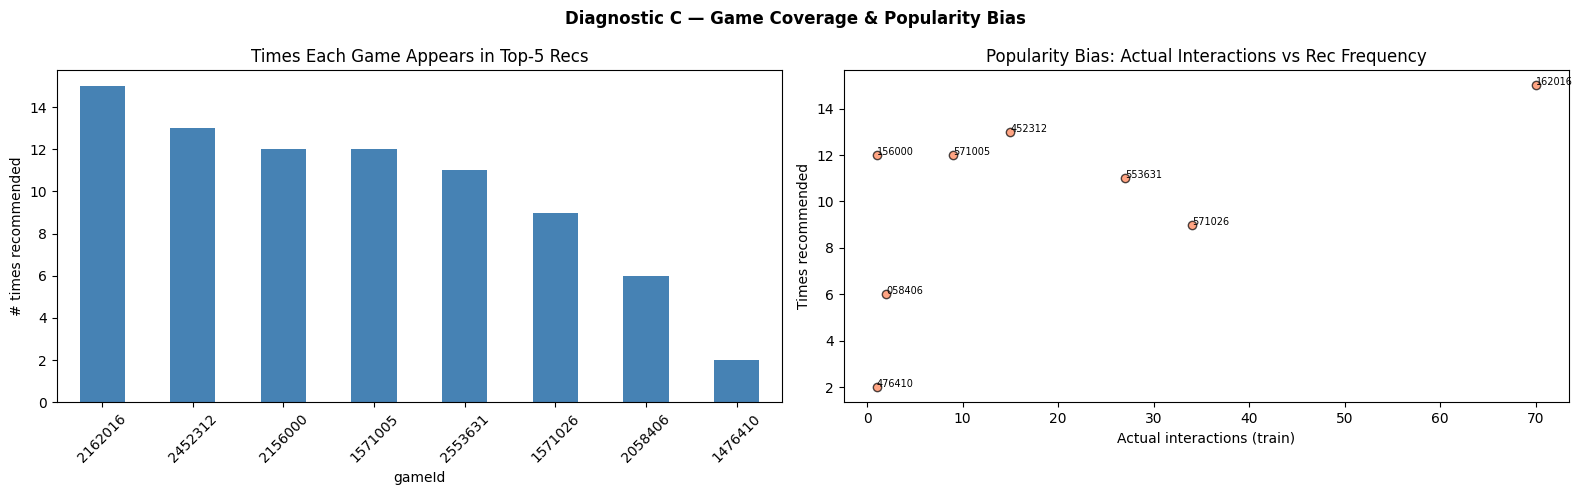

Games recommended at least once: 8 / 10
Coverage: 80.0%


In [93]:
# C: How often each game appears in top-5 recommendations across all users
from collections import Counter

all_recs = []
train_csr = to_csr(train_interactions)
n_items = train_csr.shape[1]

for uid in range(train_csr.shape[0]):
    scores = model.predict(
        user_ids=np.repeat(uid, n_items),
        item_ids=np.arange(n_items),
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
    )
    known = set(train_csr.getrow(uid).indices)
    scores[list(known)] = -np.inf
    top5 = np.argsort(scores)[-5:]
    all_recs.extend([idx_to_item[i] for i in top5])

rec_counts = pd.Series(Counter(all_recs)).sort_values(ascending=False)
actual_counts = events_df['gameId'].value_counts()

fig_c, axes_c = plt.subplots(1, 2, figsize=(16, 5))
fig_c.suptitle('Diagnostic C — Game Coverage & Popularity Bias', fontweight='bold')

rec_counts.plot(kind='bar', ax=axes_c[0], color='steelblue')
axes_c[0].set_title('Times Each Game Appears in Top-5 Recs')
axes_c[0].set_xlabel('gameId')
axes_c[0].set_ylabel('# times recommended')
axes_c[0].tick_params(axis='x', rotation=45)

# Popularity bias check: rec frequency vs actual interaction frequency
common_games = rec_counts.index.intersection(actual_counts.index)
axes_c[1].scatter(
    actual_counts[common_games].values,
    rec_counts[common_games].values,
    alpha=0.7, color='coral', edgecolors='black'
)
for g in common_games:
    axes_c[1].annotate(str(g)[-6:], (actual_counts[g], rec_counts[g]), fontsize=7)
axes_c[1].set_title('Popularity Bias: Actual Interactions vs Rec Frequency')
axes_c[1].set_xlabel('Actual interactions (train)')
axes_c[1].set_ylabel('Times recommended')

plt.tight_layout()
plt.show()

print(f'Games recommended at least once: {len(rec_counts)} / {n_items}')
print(f'Coverage: {len(rec_counts)/n_items*100:.1f}%')

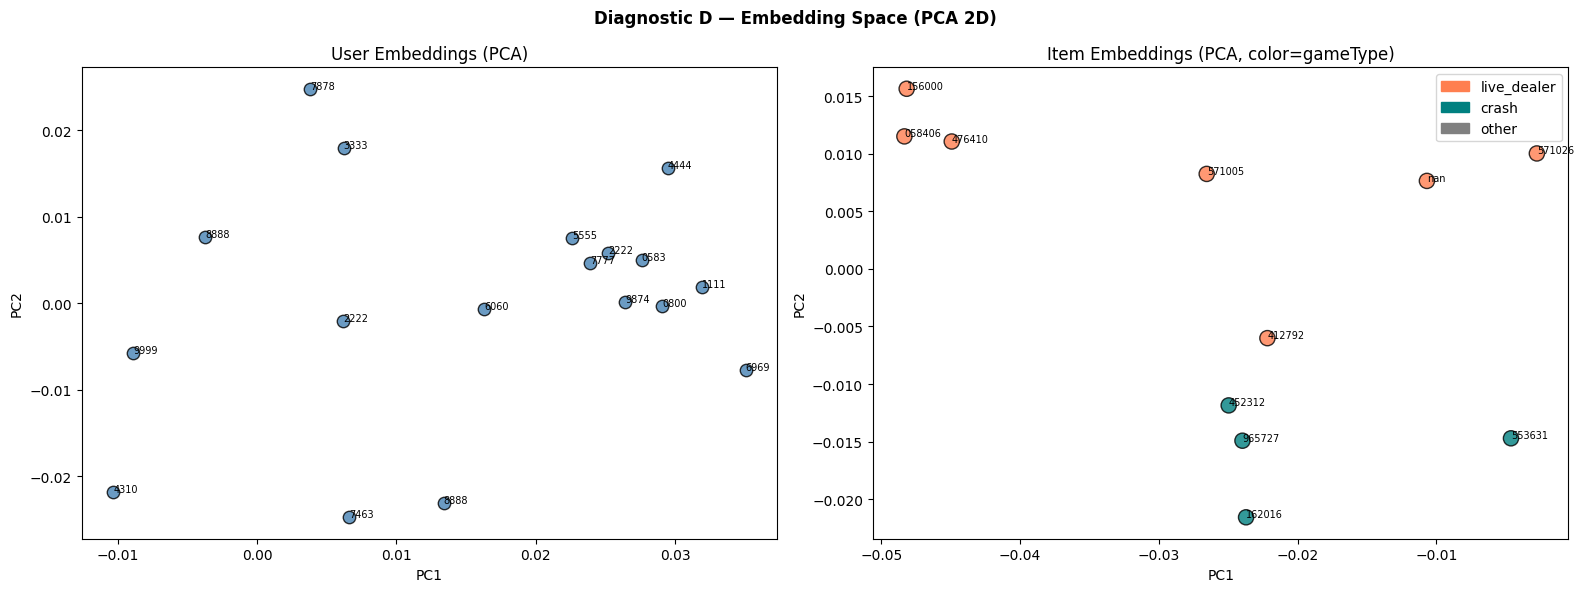

PCA explained variance: PC1=0.468, PC2=0.130


: 

: 

In [ ]:
# D: Visualize user and item embeddings in 2D via PCA
from sklearn.decomposition import PCA

user_biases, user_embeddings = model.get_user_representations(features=user_features_matrix)
item_biases, item_embeddings = model.get_item_representations(features=item_features_matrix)

pca = PCA(n_components=2, random_state=42)
all_embeddings = np.vstack([user_embeddings, item_embeddings])
all_2d = pca.fit_transform(all_embeddings)

n_u = user_embeddings.shape[0]
user_2d = all_2d[:n_u]
item_2d = all_2d[n_u:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Diagnostic D — Embedding Space (PCA 2D)', fontweight='bold')

# Users
axes[0].scatter(user_2d[:, 0], user_2d[:, 1], color='steelblue', s=80, alpha=0.8, edgecolors='black')
for i, uid in enumerate(active_users):
    axes[0].annotate(str(uid)[-4:], user_2d[i], fontsize=7)
axes[0].set_title('User Embeddings (PCA)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Items — color by game type if available
game_type_map = events_df.drop_duplicates('gameId').set_index('gameId')['gameType'].to_dict()
item_colors = [{'live_dealer': 'coral', 'crash': 'teal', 'slot': 'gold'}.get(
    game_type_map.get(gid, 'live_dealer'), 'gray') for gid in active_items]

axes[1].scatter(item_2d[:, 0], item_2d[:, 1], c=item_colors, s=120, alpha=0.8, edgecolors='black')
for i, gid in enumerate(active_items):
    axes[1].annotate(str(gid)[-6:], item_2d[i], fontsize=7)
axes[1].set_title('Item Embeddings (PCA, color=gameType)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

from matplotlib.patches import Patch
legend = [Patch(color='coral', label='live_dealer'),
          Patch(color='teal', label='crash'),
          Patch(color='gray', label='other')]
axes[1].legend(handles=legend)

plt.tight_layout()
plt.show()

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}')

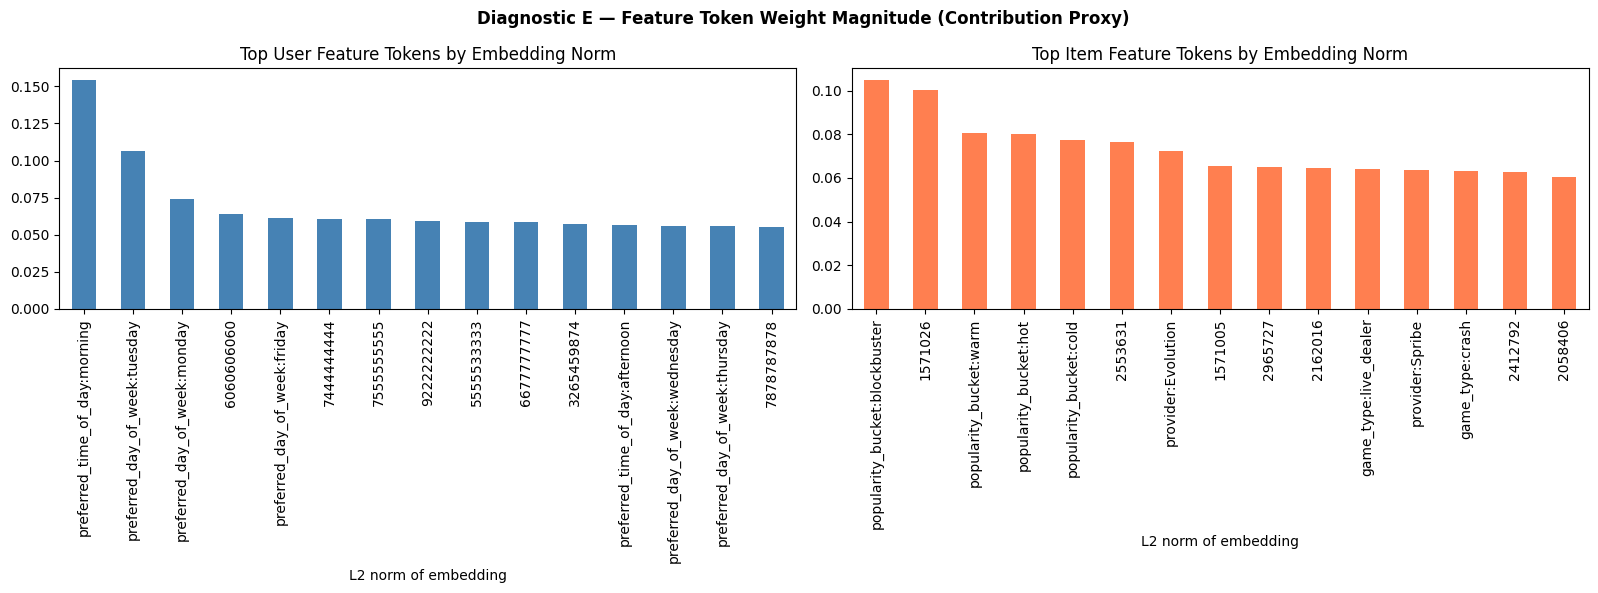

Top user tokens: {'preferred_time_of_day:morning': 0.15449891984462738, 'preferred_day_of_week:tuesday': 0.10630346089601517, 'preferred_day_of_week:monday': 0.07384131848812103, '6060606060': 0.063614621758461, 'preferred_day_of_week:friday': 0.06137796863913536}
Top item tokens: {'popularity_bucket:blockbuster': 0.10507149994373322, '1571026': 0.10047152638435364, 'popularity_bucket:warm': 0.08056120574474335, 'popularity_bucket:hot': 0.08026644587516785, 'popularity_bucket:cold': 0.0774930864572525}


In [95]:
# E: Which user/item feature tokens have highest weight magnitude in embeddings
# Proxy for feature importance in LightFM

user_feat_map = dataset.mapping()[1]  # token -> col index
item_feat_map = dataset.mapping()[3]

_, user_feat_embeddings = model.get_user_representations(features=user_features_matrix)
_, item_feat_raw = model.get_item_representations(features=item_features_matrix)

# User feature token norms (contribution proxy)
user_feat_matrix_raw = dataset.build_user_features(
    (str(r['userId']), user_tokens(r)) for _, r in ufe.iterrows()
)
user_token_norms = {}
for token, idx in user_feat_map.items():
    col = user_feat_matrix_raw.getcol(idx)
    if col.nnz > 0:
        # Get embedding row for this feature index and compute norm
        emb = model.user_embeddings[idx] if idx < model.user_embeddings.shape[0] else None
        if emb is not None:
            user_token_norms[token] = float(np.linalg.norm(emb))

item_token_norms = {}
for token, idx in item_feat_map.items():
    emb = model.item_embeddings[idx] if idx < model.item_embeddings.shape[0] else None
    if emb is not None:
        item_token_norms[token] = float(np.linalg.norm(emb))

user_contrib = pd.Series(user_token_norms).sort_values(ascending=False)
item_contrib = pd.Series(item_token_norms).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Diagnostic E — Feature Token Weight Magnitude (Contribution Proxy)', fontweight='bold')

user_contrib.head(15).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top User Feature Tokens by Embedding Norm')
axes[0].set_xlabel('L2 norm of embedding')

item_contrib.head(15).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top Item Feature Tokens by Embedding Norm')
axes[1].set_xlabel('L2 norm of embedding')

plt.tight_layout()
plt.show()

print('Top user tokens:', user_contrib.head(5).to_dict())
print('Top item tokens:', item_contrib.head(5).to_dict())

## Potential Enhancements (Discuss with Senior)

- Better session modeling when robust `sessionId`, `roundsPlayed`, and true session boundaries are fully available.
- Device and entry point enrichment from clickstream/app telemetry instead of defaults.
- Temporal sequence modeling (next-game prediction using session order, not only aggregates).
- Real-time features (recent streaks, live context) for online serving.
- Cold-start handling via metadata embeddings and business-rule fallback.
- Contextual bandits / re-ranking for exploration vs exploitation balance.
- Stronger provider/gameType normalization dictionary managed centrally.

> These are intentionally **not implemented** in this notebook yet.

In [96]:
# Final pipeline readiness report

print('=' * 70)
print('REAL-DATA RECSYS PIPELINE — READINESS REPORT')
print('=' * 70)

print('\n[1] TDD schema validation')
missing_cols = [c for c in SCHEMA_COLUMNS if c not in events_df.columns]
print('Missing schema columns:', missing_cols if missing_cols else 'None ✅')

print('\n[2] Enum coverage checks')
game_types_present = sorted(events_df['gameType'].dropna().unique().tolist())
providers_present = sorted(events_df['provider'].dropna().unique().tolist())
device_types_present = sorted(events_df['deviceType'].dropna().unique().tolist())
entry_points_present = sorted(events_df['entryPoint'].dropna().unique().tolist())
print('gameType values:', game_types_present)
print('provider values:', providers_present)
print('deviceType values:', device_types_present)
print('entryPoint values:', entry_points_present)

invalid_game_types = sorted(set(game_types_present) - set(VALID_GAME_TYPES))
invalid_providers = sorted(set(providers_present) - set(VALID_PROVIDERS))
invalid_device_types = sorted(set(device_types_present) - set(VALID_DEVICE_TYPES))
# entryPoint is intentionally semi-open to retain real source labels
non_standard_entry_points = sorted(set(entry_points_present) - set(VALID_ENTRY_POINTS))
print('Invalid gameType values:', invalid_game_types if invalid_game_types else 'None ✅')
print('Invalid provider values:', invalid_providers if invalid_providers else 'None ✅')
print('Invalid deviceType values:', invalid_device_types if invalid_device_types else 'None ✅')
print('Additional entryPoint values retained from source:', non_standard_entry_points if non_standard_entry_points else 'None')

print('\n[3] Output datasets')
print(f'events_df:       {events_df.shape}')
print(f'user_features_df:{user_features_df.shape}')
print(f'game_features_df:{game_features_df.shape}')
print(f'user_game_df:    {user_game_df.shape}')
print(f'model_ready_df:  {model_ready_df.shape}')

print('\n[4] Context field coverage')
device_unknown_rate = (events_df['deviceType'].eq('unknown').mean() * 100) if len(events_df) else 0
entry_unknown_rate = (events_df['entryPoint'].eq('unknown').mean() * 100) if len(events_df) else 0
print(f'deviceType unknown rate: {device_unknown_rate:.2f}%')
print(f'entryPoint unknown rate: {entry_unknown_rate:.2f}%')

if 'deviceType_raw' in transactions_df.columns:
    print('\nTop deviceType raw -> mapped pairs:')
    sample_map = pd.DataFrame({
        'raw': transactions_df['deviceType_raw'].astype(str).fillna('nan'),
        'mapped': transactions_df['deviceType_raw'].astype(str).map(map_device_type)
    })
    print(sample_map.value_counts().head(8))

if 'entryPoint_raw' in transactions_df.columns:
    print('\nTop entryPoint raw -> mapped pairs:')
    sample_map = pd.DataFrame({
        'raw': transactions_df['entryPoint_raw'].astype(str).fillna('nan'),
        'mapped': transactions_df['entryPoint_raw'].astype(str).map(map_entry_point)
    })
    print(sample_map.value_counts().head(12))

print('\nPipeline is schema-aligned and ready for downstream model training steps.')
print('=' * 70)

REAL-DATA RECSYS PIPELINE — READINESS REPORT

[1] TDD schema validation
Missing schema columns: None ✅

[2] Enum coverage checks
gameType values: ['crash', 'live_dealer']
provider values: ['Evolution', 'OnlyPlay', 'Spribe']
deviceType values: ['unknown']
entryPoint values: ['livecasino', 'unknown']
Invalid gameType values: None ✅
Invalid provider values: None ✅
Invalid deviceType values: None ✅
Additional entryPoint values retained from source: None

[3] Output datasets
events_df:       (169, 17)
user_features_df:(16, 17)
game_features_df:(10, 11)
user_game_df:    (30, 13)
model_ready_df:  (30, 38)

[4] Context field coverage
deviceType unknown rate: 100.00%
entryPoint unknown rate: 89.94%

Top deviceType raw -> mapped pairs:
raw  mapped 
nan  unknown    179
Name: count, dtype: int64

Top entryPoint raw -> mapped pairs:
raw         mapped    
nan         unknown       161
livecasino  livecasino     18
Name: count, dtype: int64

Pipeline is schema-aligned and ready for downstream model 

In [97]:
# Context fields validation after real-source integration
print(events_df['deviceType'].value_counts(dropna=False))
print(events_df['entryPoint'].value_counts(dropna=False))

# implicit_score range check (if available)
if 'user_game_df' in globals() and 'implicit_score' in user_game_df.columns:
    print(user_game_df['implicit_score'].describe())
else:
    print('user_game_df not built yet in current run; skip implicit_score check.')

deviceType
unknown    169
Name: count, dtype: int64
entryPoint
unknown       152
livecasino     17
Name: count, dtype: int64
count    30.00000
mean      0.42489
std       0.13836
min       0.20690
25%       0.33350
50%       0.39405
75%       0.46625
max       0.75320
Name: implicit_score, dtype: float64


: 